# Rossmann store-sales analysis

Rossmann is a drug-store chain with more than 3,000 shops across Europe. Every day, each store manager has to decide how many staff to schedule and how much stock to hold, and both decisions depend on how much the shop is likely to sell. Forecasting daily sales accurately, up to six weeks ahead, is therefore a real business problem.

This notebook works on the Rossmann sales data that was released as a public forecasting competition. It is written as one self-contained study, and it is organised so that each part is explained in plain terms before any technical detail:

1. **Setting up**: what the data is and how it is loaded.
2. **Understanding the data**: the tables, the columns, and what a forecast looks like.
3. **Checking the data**: completeness and consistency, before any pattern is trusted.
4. **Exploring the data**: how sales behave across shops, weekdays, months and promotions.
5. **Forecasting sales for every store**: several families of methods compared on the same historical windows, ending with a forecast for the competition period.
6. **Conclusions**: what the comparison supports, and what to do before using it for real.

Throughout, observed results are kept separate from explanations, and anything the data cannot answer is stated rather than guessed.


## 01 - SETTING UP

### What we are working with

The data describes one retail chain, and it comes in a few related tables:

- a **store** table, listing each shop and some facts about it;
- a **train** table of historical daily sales, one row per shop per day;
- a **test** table for the coming six-week period, with the same shops and dates but without the sales;
- a **sample submission** file, showing the shape the final answer must take.

Our job is to use the history to forecast the sales in the test period.

### What this notebook does

We first make sure we understand and trust the data, then explore how sales behave, and finally compare several forecasting methods on the same footing: simple baselines, classical statistical models, machine learning, and deep learning. Every method is judged the same way, on sales it has not seen, across all shops.

### Loading the tools and the files

The next two cells load the Python libraries we need and read the four CSV files. If the data cannot be found, the notebook stops with a clear message instead of failing later in a confusing place.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
possible_data_dirs = [
    Path.cwd() / "datasets" / "rossmann-store-sales",
    Path.cwd().parent / "datasets" / "rossmann-store-sales",
]
DATA_DIR = next((candidate.resolve() for candidate in possible_data_dirs if candidate.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find datasets/rossmann-store-sales from the notebook folder. "
        "Place the data folder under the project or update possible_data_dirs."
    )

store = pd.read_csv(DATA_DIR / "store.csv")
train = pd.read_csv(DATA_DIR / "train.csv", dtype={"StateHoliday": "string"})
test = pd.read_csv(DATA_DIR / "test.csv", dtype={"StateHoliday": "string"})
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

## 02 - UNDERSTANDING THE DATA

The data is not a single table. It carries two kinds of information, and it helps to separate them before looking at any numbers.

- **Store information**: one row per shop, describing the shop and its surroundings. There are 1,115 shops in total.
- **Daily sales**: one row per shop per day. This is split into two files:
  - a **training** file covering the past (2013 to mid 2015), which includes the sales figures we learn from;
  - a **test** file covering the six weeks we are asked to predict (August to September 2015), which has the shop and calendar details but not the sales, because those are exactly what we must produce.

A separate **sample submission** file shows how our predictions must be laid out. The rest of this section looks at each table and explains every column in plain terms.


### 2.1 The store table

This table has one row per shop and describes each shop with a handful of properties:

- **Store**: the shop's ID number. It is the key that links this table to the daily sales.
- **StoreType**: the format of the shop, encoded as a, b, c or d. Different formats can have different sizes and trading patterns.
- **Assortment**: the range of products the shop carries (a, b or c), from basic to extended.
- **CompetitionDistance**: how far away the nearest competitor is, in metres.
- **CompetitionOpenSinceMonth** and **CompetitionOpenSinceYear**: roughly when that competitor opened.
- **Promo2**: whether the shop takes part in a long-running, repeated promotion programme (0 or 1).
- **Promo2SinceWeek**, **Promo2SinceYear** and **PromoInterval**: since when it takes part, and in which months the promotion repeats.

Two things about the blanks in this table are worth stating early. The Promo2 fields are empty for shops that do not take part in that programme, so the blank means "not applicable", not "unknown". And where the competitor fields are empty, the data simply did not record a competitor, which is different from a competitor being zero metres away. We keep these blanks as blanks rather than inventing values.


In [3]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### 2.2 The daily sales tables

In both the training and the test file, each row is one shop on one date. The columns are:

- **Store**: which shop the row belongs to.
- **Date** and **DayOfWeek**: the calendar day.
- **Sales**: how much the shop sold that day, the number we want to forecast. It appears only in the training file.
- **Customers**: how many customers visited that day. It appears only in the history, so it can never be used to forecast the future, because we only know it after the fact.
- **Open**: whether the shop was open (1) or closed (0) that day. Closed days have zero sales.
- **Promo**: whether the shop ran a promotion that day.
- **StateHoliday** and **SchoolHoliday**: whether the day was a public or school holiday.

The training file is our past, with sales to learn from. The test file is the future we must fill in: it repeats the shop and calendar columns, but with no sales column.


In [4]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


### 2.3 How a forecast is submitted

The test file gives every row an **Id**. When we submit predictions, each number is matched back to a test row by that Id, so the Id is the thread that ties our forecast to the right shop and date. A quick check confirms that the test file and the sample submission use exactly the same Ids, one each, so our output cannot end up misaligned.


In [6]:
if not test["Id"].is_unique or not sample_submission["Id"].is_unique:
    raise ValueError("Test and sample-submission Id values must be unique")

if set(test["Id"]) != set(sample_submission["Id"]):
    raise ValueError("Test Id values do not match the sample-submission Id values")

print("Every test row has exactly one matching Id in the sample submission, so the two files line up one to one.")

Every test row has exactly one matching Id in the sample submission, so the two files line up one to one.


## 03 - CHECKING THE DATA BEFORE WE TRUST IT

Before reading anything into the sales patterns, we check that the data is complete, consistent, and shaped the way we expect. This is not a formality. A gap in the history, or a mismatch between two columns, would quietly distort every conclusion that follows.

The checks below ask how much data there is, where values are missing, whether any shop or date is duplicated or absent, whether the calendar fields agree with one another, and whether sales line up with the opening status. We work on copies of the files, and we never silently fill a missing value or delete a row.


### 3.1 How much data we have

First we simply measure the data. The store table should describe each shop once. The training file should cover a continuous stretch of daily sales, and the test file should cover the six-week forecast period. Printing the number of rows, shops and dates makes clear how much history we have and over what period, which everything later depends on.


In [7]:
print(f"Store table: {len(store):,} rows, one per shop ({store['Store'].nunique():,} shops)")
print(
    f"Training sales: {len(train):,} rows, {train['Store'].nunique():,} shops, "
    f"{pd.to_datetime(train['Date']).min():%Y-%m-%d} to "
    f"{pd.to_datetime(train['Date']).max():%Y-%m-%d}"
)
print(
    f"Test period: {len(test):,} rows, {test['Store'].nunique():,} shops, "
    f"{pd.to_datetime(test['Date']).min():%Y-%m-%d} to "
    f"{pd.to_datetime(test['Date']).max():%Y-%m-%d}"
)
print(f"Sample submission: {len(sample_submission):,} rows, one per test row")

Store table: 1,115 rows, one per shop (1,115 shops)
Training sales: 1,017,209 rows, 1,115 shops, 2013-01-01 to 2015-07-31
Test period: 41,088 rows, 856 shops, 2015-08-01 to 2015-09-17
Sample submission: 41,088 rows, one per test row


### 3.2 Checking for missing values

Next we look for blanks. A blank can mean different things. In the store table, some blanks are expected (a shop that does not take part in Promo2 has nothing to put in the Promo2 columns), while others are genuine gaps (a competitor whose details were never recorded). In the daily tables, a blank would be a real problem, because every row is meant to carry a full day's record.

We count the blanks column by column, so we can decide field by field whether a blank is meaningful or a gap, and whether it needs any action at all.


In [8]:
table_names = {"store": "store table", "train": "training data", "test": "test data"}
for name, frame in (("store", store), ("train", train), ("test", test)):
    missing_count = frame.isna().sum()
    missing_percent = (missing_count / len(frame) * 100).round(2)
    missing_report = pd.DataFrame({
        "missing values": missing_count,
        "share of rows (%)": missing_percent,
    })

    print(f"\nMissing values in the {table_names[name]}:")
    display(missing_report)


Missing values in the store table:


,missing values,share of rows (%)
Store,0,0.00
StoreType,0,0.00
Assortment,0,0.00
CompetitionDistance,3,0.27
CompetitionOpenSinceMonth,354,31.75
CompetitionOpenSinceYear,354,31.75
Promo2,0,0.00
Promo2SinceWeek,544,48.79
Promo2SinceYear,544,48.79
PromoInterval,544,48.79



Missing values in the training data:


,missing values,share of rows (%)
Store,0,0.0
DayOfWeek,0,0.0
Date,0,0.0
Sales,0,0.0
Customers,0,0.0
Open,0,0.0
Promo,0,0.0
StateHoliday,0,0.0
SchoolHoliday,0,0.0



Missing values in the test data:


,missing values,share of rows (%)
Id,0,0.00
Store,0,0.00
DayOfWeek,0,0.00
Date,0,0.00
Open,11,0.03
Promo,0,0.00
StateHoliday,0,0.00
SchoolHoliday,0,0.00


Reading the blanks:

- In the **store** table, the Promo2 fields (Promo2SinceWeek, Promo2SinceYear, PromoInterval) are empty for 544 shops. Those are the shops that do not take part in the Promo2 programme, so the blank means "not applicable". The competitor's opening month and year are missing for 354 shops, and the competitor distance for 3, so for those shops the data simply did not record a competitor. None of these are values we can or should invent.
- The **training** file has no blanks at all, which is what we want in daily history.
- The **test** file has 11 blank Open values out of 41,088 rows. All 11 belong to the same shop, Store 622, over a few days in September 2015. This is one concentrated gap, not scattered missingness, and a blank Open does not tell us the shop was closed. We hold those values as unknown and do not treat them as closed.


### 3.3 Checking for duplicate and missing dates

Two different questions sit behind the word "coverage". The first is whether any row is duplicated, meaning the same shop on the same day recorded twice. The second is whether any expected shop-day is missing entirely.

Both matter, but the second is easy to overlook. A table can have no blanks and no duplicate rows and still be missing whole days for whole groups of shops. So we check for duplicates, then build the complete list of shop-days that should exist and count how many are absent.


In [9]:
store_repeats = store.duplicated(subset="Store").sum()
train_repeats = train.duplicated(subset=["Store", "Date"]).sum()
test_repeats = test.duplicated(subset=["Store", "Date"]).sum()

print("Duplicated shop rows in the store table:", store_repeats)
print("Duplicated shop-day rows in the training data:", train_repeats)
print("Duplicated shop-day rows in the test data:", test_repeats)

# Unique keys do not guarantee that every expected store-date row is present.
train_calendar = train.assign(Date=pd.to_datetime(train["Date"]))
calendar_dates = pd.date_range(
    train_calendar["Date"].min(), train_calendar["Date"].max(), freq="D",
)
observed_days_per_store = train_calendar.groupby("Store")["Date"].nunique()
missing_days_per_store = len(calendar_dates) - observed_days_per_store
expected_store_date_rows = store["Store"].nunique() * len(calendar_dates)
missing_store_date_rows = expected_store_date_rows - len(train_calendar)
complete_store_ids = observed_days_per_store[
    observed_days_per_store == len(calendar_dates)
].index

print("Shop-days expected if every shop had every day:", expected_store_date_rows)
print("Shop-days actually missing:", missing_store_date_rows)
print("Calendar days covered by the history:", len(calendar_dates))
print("Shops with a complete history:", len(complete_store_ids))
print("Shops with at least one missing day:", int(missing_days_per_store.gt(0).sum()))
display(
    missing_days_per_store.value_counts().sort_index()
    .rename_axis("missing days")
    .to_frame("shops")
)

# This identifies the shared reporting gap that changes the pooled-store mix.
monthly_store_coverage = train_calendar.groupby(
    train_calendar["Date"].dt.to_period("M")
)["Store"].nunique()
display(monthly_store_coverage.loc["2014-06":"2015-01"].rename("shops with rows").to_frame())

test_calendar = test.assign(Date=pd.to_datetime(test["Date"]))
test_dates = pd.date_range(
    test_calendar["Date"].min(), test_calendar["Date"].max(), freq="D",
)
test_days_per_store = test_calendar.groupby("Store")["Date"].nunique()
print("Days each shop covers in the test file:", sorted(test_days_per_store.unique()))
if not test_days_per_store.eq(len(test_dates)).all():
    raise ValueError("Test does not contain the same complete date range for every store")

Duplicated shop rows in the store table: 0
Duplicated shop-day rows in the training data: 0
Duplicated shop-day rows in the test data: 0


Shop-days expected if every shop had every day: 1050330
Shop-days actually missing: 33121
Calendar days covered by the history: 942
Shops with a complete history: 934
Shops with at least one missing day: 181


,shops
missing days,
0,934
1,1
184,180


,shops with rows
Date,
2014-06,1115
2014-07,935
2014-08,935
2014-09,935
2014-10,935
2014-11,935
2014-12,935
2015-01,1115


Days each shop covers in the test file: [np.int64(48)]


Reading the coverage:

- There are no duplicated shop rows and no duplicated shop-day rows.
- The history is not a complete grid. If every shop had a row for every day, there would be 1,050,330 shop-days; 33,121 of them are absent. Almost all of the gap is a single block: 180 shops have no records at all between 1 July and 31 December 2014. One other shop, Store 988, is missing a single day, 1 January 2013.
- During that six-month stretch, each day has 935 shops instead of 1,115.

These are absent rows, not days the shops were closed. The files do not explain why the records are missing, so we must not fill them with zero sales or treat them as closures. The gap also changes which shops are included in any pooled monthly average, which is why we later compare pooled figures against a fixed set of shops. The forecast itself keeps every shop and date the data provides.


### 3.4 Keeping the original data intact

All the tidying below happens on copies of the three tables. The originals stay untouched, so every change can be compared against what was loaded and the work stays auditable.


In [10]:
train_clean = train.copy()
test_clean = test.copy()
store_clean = store.copy()

print("Row counts before and after copying:")
print("  training:", len(train), "->", len(train_clean))
print("  test:", len(test), "->", len(test_clean))
print("  store:", len(store), "->", len(store_clean))

Row counts before and after copying:
  training: 1017209 -> 1017209
  test: 41088 -> 41088
  store: 1115 -> 1115


### 3.5 Giving each column the right data type

Now we tell pandas what each column actually is. Dates become real dates; holiday and store-type labels become categories; and the binary fields (Open, Promo, SchoolHoliday, DayOfWeek) become nullable integers. "Nullable" matters for one column in particular: Open is missing for those 11 test rows, and we want that missing value to remain clearly different from a zero. Where a value cannot be converted, we let the notebook stop rather than quietly coerce it, so a malformed entry cannot slip through unnoticed.


In [11]:
for frame in (train_clean, test_clean):
    frame["Date"] = pd.to_datetime(frame["Date"], errors="raise")
    frame["StateHoliday"] = frame["StateHoliday"].astype("string").str.strip().astype("category")

    for column in ("DayOfWeek", "Open", "Promo", "SchoolHoliday"):
        frame[column] = pd.to_numeric(frame[column], errors="raise").astype("Int8")

for column in ("StoreType", "Assortment"):
    store_clean[column] = store_clean[column].astype("category")

store_clean["PromoInterval"] = store_clean["PromoInterval"].astype("string")

print("Column types after conversion (training data):")
print(train_clean.dtypes)
print("\nPublic and holiday labels in the training data, with counts:")
print(train_clean["StateHoliday"].value_counts(dropna=False))

Column types after conversion (training data):
Store                     int64
DayOfWeek                  Int8
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                       Int8
Promo                      Int8
StateHoliday           category
SchoolHoliday              Int8
dtype: object

Public and holiday labels in the training data, with counts:


StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


Reading the result: every column converted without error, including the holiday labels, which are the letters a, b, c and 0. This confirms the columns can be stored in these types; it does not yet prove the values are correct. The next checks test that.


### 3.6 Checking that the date and weekday agree

Every daily row carries both a Date and a DayOfWeek, so the two should always agree: a date that falls on a Monday should be labelled Monday. Because they carry the same information, a mismatch would point to a data-entry error. Rossmann numbers the days Monday = 1 through Sunday = 7, so we convert pandas' convention (Monday = 0) before comparing, then count any disagreements.


In [12]:
for name, frame in (("train", train_clean), ("test", test_clean)):
    expected_day = (frame["Date"].dt.dayofweek + 1).astype("Int8")
    mismatch_count = frame["DayOfWeek"].ne(expected_day).sum()

    print(f"{name}: rows where the weekday label disagrees with the date = {mismatch_count}")
    assert mismatch_count == 0, f"Found weekday/date mismatches in {name}"

print("\nExample of the converted dates and their weekday labels:")
display(train_clean[["Date", "DayOfWeek"]].head())

train: rows where the weekday label disagrees with the date = 0
test: rows where the weekday label disagrees with the date = 0

Example of the converted dates and their weekday labels:


,Date,DayOfWeek
0,2015-07-31,5
1,2015-07-31,5
2,2015-07-31,5
3,2015-07-31,5
4,2015-07-31,5


Reading the result: there are zero mismatches in both the training and the test data, so the date and weekday fields tell a consistent story throughout. Either one can be used to build weekday features.


### 3.7 Checking sales against opening status

The column we forecast is Sales, and Open tells us whether the shop was trading. The two should line up: a closed shop should sell nothing, and an open shop should normally sell something. We look at them together, and we also look at the handful of test rows where Open is unknown, because that uncertainty affects how a forecast should be handled.

One point of care: Open records what happened, and it is not a substitute for missing data. We should not assume that a missing Open means the shop was closed.


In [13]:
print("Summary of daily sales in the training data:")
display(train_clean["Sales"].describe().to_frame())

if train_clean["Sales"].isna().any() or (train_clean["Sales"] < 0).any():
    raise ValueError("Training Sales contains missing or negative values")

sales_by_open = train_clean.groupby("Open", dropna=False)["Sales"].agg(["size", "min", "median", "max"])
print("Sales split by whether the shop was open or closed:")
display(sales_by_open)

open_zero_sales = train_clean.loc[(train_clean["Open"] == 1) & (train_clean["Sales"] == 0)]
print("Open days that recorded zero sales:", len(open_zero_sales))
print("Shops involved:", open_zero_sales["Store"].nunique())
print("Of those rows, how many also recorded zero customers:", int(open_zero_sales["Customers"].eq(0).sum()))
display(open_zero_sales[["Store", "Date", "DayOfWeek", "Sales", "Customers", "Promo"]].head(12))

unknown_open = test_clean.loc[test_clean["Open"].isna(), [
    "Id", "Store", "Date", "DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday",
]].sort_values(["Store", "Date"])
print("Test rows with an unknown opening status:", len(unknown_open))
display(unknown_open)

Summary of daily sales in the training data:


,Sales
count,1.017209e+06
mean,5.773819e+03
std,3.849926e+03
min,0.000000e+00
25%,3.727000e+03
50%,5.744000e+03
75%,7.856000e+03
max,4.155100e+04


Sales split by whether the shop was open or closed:


,size,min,median,max
Open,,,,
0,172817,0,0.0,0
1,844392,0,6369.0,41551


Open days that recorded zero sales: 54
Shops involved: 41
Of those rows, how many also recorded zero customers: 52


,Store,Date,DayOfWeek,Sales,Customers,Promo
86825,971,2015-05-15,5,0,0,0
142278,674,2015-03-26,4,0,0,0
196938,699,2015-02-05,4,0,0,1
322053,708,2014-10-01,3,0,0,1
330176,357,2014-09-22,1,0,0,0
340348,227,2014-09-11,4,0,0,0
340860,835,2014-09-11,4,0,0,0
341795,835,2014-09-10,3,0,0,0
346232,548,2014-09-05,5,0,0,1
346734,28,2014-09-04,4,0,0,1


Test rows with an unknown opening status: 11


,Id,Store,Date,DayOfWeek,Promo,StateHoliday,SchoolHoliday
10751,10752,622,2015-09-05,6,0,0,0
9039,9040,622,2015-09-07,1,0,0,0
8183,8184,622,2015-09-08,2,0,0,0
7327,7328,622,2015-09-09,3,0,0,0
6471,6472,622,2015-09-10,4,0,0,0
5615,5616,622,2015-09-11,5,0,0,0
4759,4760,622,2015-09-12,6,0,0,0
3047,3048,622,2015-09-14,1,1,0,0
2191,2192,622,2015-09-15,2,1,0,0
1335,1336,622,2015-09-16,3,1,0,0


Reading the result:

- Every closed day in the training data has Sales of zero, exactly as expected.
- Among the open days, 54 rows also show zero sales, spread across 41 shops, and most of them record zero customers too. These are a small but genuine inconsistency: the row says the shop was open, yet it sold nothing. The data does not tell us whether these are reporting mistakes or real, quiet open days, so we leave them as they are rather than rewriting history.
- The 11 unknown Open values in the test file all belong to Store 622, from 5 to 17 September 2015. We will forecast those rows as though the shop were open, and flag them, rather than assume it was closed.


### 3.8 Adding store details to the daily sales

The daily tables tell us what happened on each day, but not what kind of shop it was. To bring the two together, we join the store table onto each daily row using the shop ID as the key. This is a "many to one" join: many daily rows share one shop, but each shop appears once in the store table. We check that the join neither drops rows nor duplicates them.


In [14]:
train_unknown_stores = set(train_clean["Store"]) - set(store_clean["Store"])
test_unknown_stores = set(test_clean["Store"]) - set(store_clean["Store"])

print("Training shops missing from the store table:", len(train_unknown_stores))
print("Test shops missing from the store table:", len(test_unknown_stores))

assert store_clean["Store"].is_unique, "The store lookup has repeated Store IDs"
assert not train_unknown_stores, "Some train Store IDs have no store description"
assert not test_unknown_stores, "Some test Store IDs have no store description"

train_model = train_clean.merge(
    store_clean,
    on="Store",
    how="left",
    validate="many_to_one",
)
test_model = test_clean.merge(
    store_clean,
    on="Store",
    how="left",
    validate="many_to_one",
)

print("\nRow counts before and after adding store details:")
print("  training:", len(train_clean), "->", len(train_model))
print("  test:", len(test_clean), "->", len(test_model))

assert len(train_model) == len(train_clean)
assert len(test_model) == len(test_clean)

Training shops missing from the store table: 0
Test shops missing from the store table: 0



Row counts before and after adding store details:
  training: 1017209 -> 1017209
  test: 41088 -> 41088


Reading the result: every shop in the daily data has a matching entry in the store table, and the store key is unique. The join leaves the row counts exactly as they were (1,017,209 training rows and 41,088 test rows), so no daily record was lost or multiplied.


### 3.9 What is still missing, and what we will not guess

After the join we are left with the blanks the data genuinely has: three missing competitor distances, 354 missing competitor opening dates, and the Promo2 fields that are blank for non-participating shops. We also still have the 11 unknown Open values in the test file. None of these are filled here. The forecasting models below use columns that are complete, and the unknown opening days are handled explicitly at the forecast step rather than assumed to be closures.


In [15]:
print("Shape of the joined tables (rows, columns):")
print("  training:", train_model.shape)
print("  test:", test_model.shape)

print("\nBlanks still present in the store table:")
display(store_clean.isna().sum().rename("missing values").to_frame())

print("\nA few rows of the joined training data:")
display(train_model[["Store", "Date", "Sales", "Open", "Promo", "StoreType", "Assortment"]].head())

Shape of the joined tables (rows, columns):
  training: (1017209, 18)
  test: (41088, 17)

Blanks still present in the store table:


,missing values
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544



A few rows of the joined training data:


,Store,Date,Sales,Open,Promo,StoreType,Assortment
0,1,2015-07-31,5263,1,1,c,a
1,2,2015-07-31,6064,1,1,a,a
2,3,2015-07-31,8314,1,1,a,a
3,4,2015-07-31,13995,1,1,c,c
4,5,2015-07-31,4822,1,1,a,a


The joined tables retain the three missing competitor distances and the 354 missing competitor opening dates. Promo2 metadata remains blank for its 544 non-participating stores by design. These fields are not used in the one-store forecast models, so no imputation is needed here.

The 11 missing test Open values are a separate problem from missing store metadata. They are outside the Store 1 comparison but prevent a fully specified all-store workflow unless resolved from a defensible source or handled with an explicit unknown-status policy. Customers is excluded from forecasting because it is unavailable in test.

## 04 - EXPLORING THE DATA

Now that the data is checked and joined, we look at how sales actually behave. The aim is to understand the shape of the numbers before trying to forecast them: how large sales are, how much they vary from day to day, how they move through the week and the year, whether promotions line up with higher sales, and how different shops compare.

Most of the summaries look only at **open** days, because a closed day has zero sales by definition and adding those zeros would blur the picture of trading. When we forecast, however, we keep every calendar day, including closures, because the forecast has to cover the real calendar.


A practical note before we start. Because 180 shops are missing the second half of 2014, a simple average across all shops would quietly change its shop mix partway through the year. To see genuine movement over time, we therefore also compute an "equal-shop" version that uses only the 934 shops with a complete history, and we compare the two.


### 4.1 How much does a shop sell on an open day?

We start with the overall spread of sales on open days. A histogram and a set of quantiles show where a typical day sits, how far the busiest days stretch, and how much natural variation there is. This sets a sense of scale for everything else, and it shows that sales are highly uneven: most days sit in a middle band, while the busiest days are far above it.


Open shop-days in the training data: 844,392


,Sales
min,0.0
25%,4859.0
median,6369.0
75%,8360.0
90%,10771.0
99%,17789.0
max,41551.0


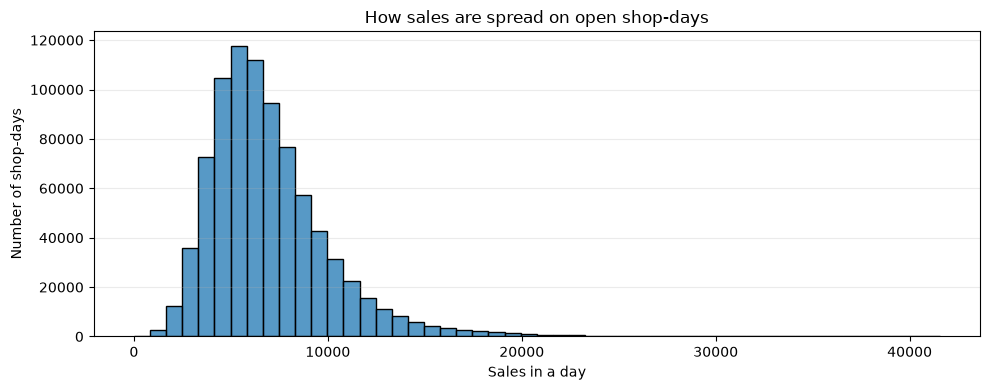

In [16]:
open_sales = train_model.loc[train_model["Open"] == 1, "Sales"]
sales_quantiles = open_sales.quantile([0.00, 0.25, 0.50, 0.75, 0.90, 0.99, 1.00])
sales_quantiles.index = ["min", "25%", "median", "75%", "90%", "99%", "max"]
print(f"Open shop-days in the training data: {len(open_sales):,}")
display(sales_quantiles.rename("Sales").to_frame())

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(open_sales, bins=50, ax=ax)
ax.set(title="How sales are spread on open shop-days", xlabel="Sales in a day", ylabel="Number of shop-days")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Reading the distribution: across 844,392 open shop-days, half the days sell below about 6,369, and nine days in ten sell below about 10,771. The top one percent reach close to 17,789, and the highest single day is 41,551. Sales are therefore strongly skewed to the right, with a long tail of very busy days. The single maximum is not by itself an error, so we keep it.

One detail to note: the minimum is zero because the distribution includes the 54 open rows that recorded no sales, the ones we flagged while checking the data. And because this pools every shop, date and promotion together, it describes the chain in general, not any one shop.


### 4.2 One shop's sales over time

Numbers alone are hard to picture, so we look at a single shop, Store 1, across its full history. Plotting its daily sales in date order shows both the day-to-day movement and, very clearly, the regular pattern of closures.


Store 1: 942 days of history


,Date,Sales,Open,Promo
1016095,2013-01-01,0,0,0
1014980,2013-01-02,5530,1,0
1013865,2013-01-03,4327,1,0
1012750,2013-01-04,4486,1,0
1011635,2013-01-05,4997,1,0


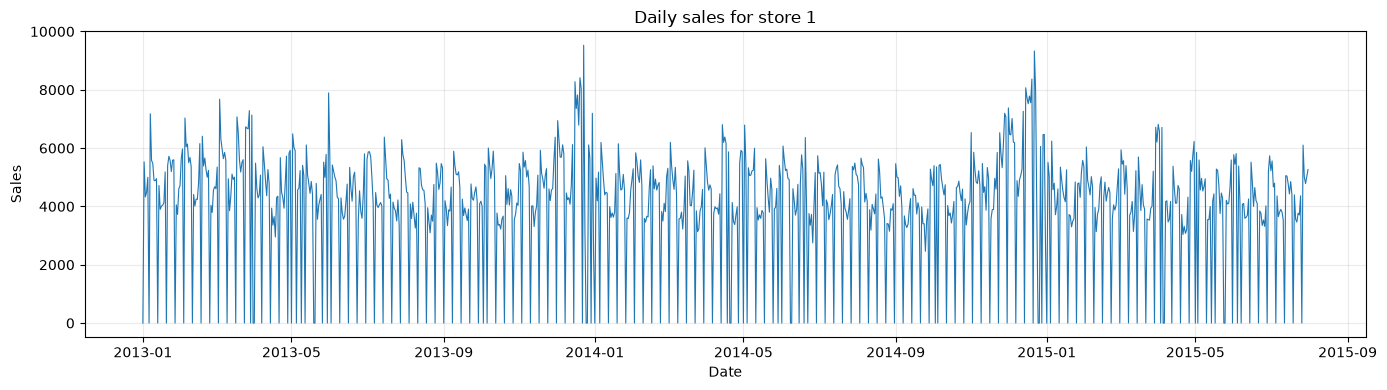

In [17]:
store_id = 1
one_store = (
    train_model.loc[train_model["Store"] == store_id]
    .sort_values("Date")
)

print(f"Store {store_id}: {len(one_store):,} days of history")
display(one_store[["Date", "Sales", "Open", "Promo"]].head())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(one_store["Date"], one_store["Sales"], linewidth=0.8)
ax.set(title=f"Daily sales for store {store_id}", xlabel="Date", ylabel="Sales")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Reading Store 1: over its 942 days it was open 781 times and closed 161 times, and every one of its 134 Sundays was closed. The regular dips to zero are therefore that shop's weekly closing pattern, not days of zero trading while open. Between those closures, sales still rise and fall, so the weekly rhythm and the day-to-day variation are two separate things.

Store 1's history spans about two and a half years. That is long enough to see weekly repetition and multi-month changes, but not long enough to be certain about a stable, repeating annual pattern.


### 4.3 Zooming into a few months

To see the weekly pattern more clearly, we zoom into the first three months of Store 1. The short window makes it easier to tell the repeated closures apart from ordinary variation on the days the shop is open. This is a closer look at the same data, not a separate sample.


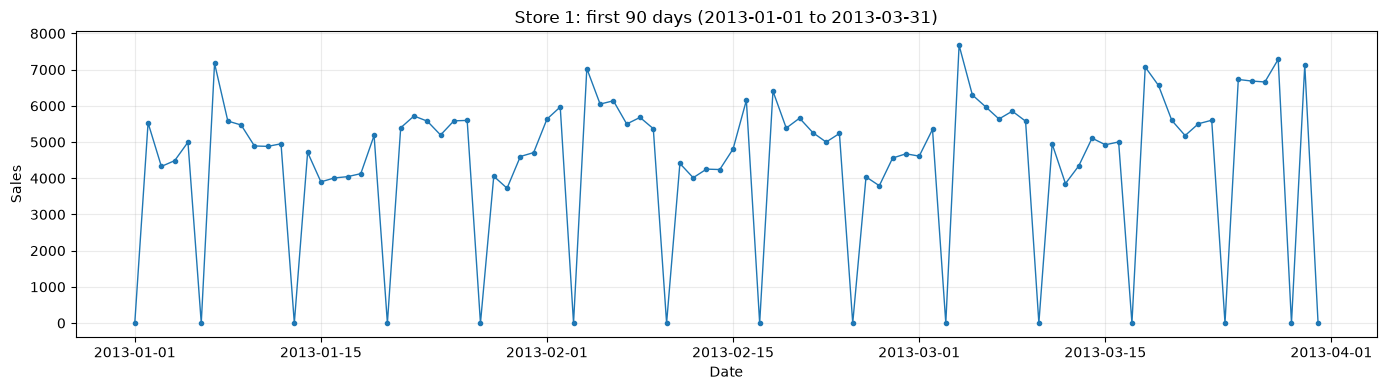

In [18]:
zoom_start = one_store["Date"].min()
zoom_end = zoom_start + pd.Timedelta(days=89)
zoomed_store = one_store.loc[one_store["Date"].between(zoom_start, zoom_end)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(zoomed_store["Date"], zoomed_store["Sales"], marker=".", linewidth=1)
ax.set(
    title=f"Store {store_id}: first 90 days ({zoom_start:%Y-%m-%d} to {zoom_end:%Y-%m-%d})",
    xlabel="Date",
    ylabel="Sales",
)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Reading the zoom: the closures fall on the same weekday each week, while the open days still move up and down noticeably. That is why the forecast keeps a daily series that includes the closure dates, and why the models are given the opening status as a known input wherever it is available.


### 4.4 Comparing a few shops

Shops are not identical, so we compare a handful of them side by side. We pick six shops at random (with a fixed seed, so the same six appear each time) and plot their open-day sales across the whole period, together with a small table of facts: how many Sundays are open, how many other days are closed, and how high and how varied their sales are.


,Recorded days,Missing dates,Sundays recorded,Sundays open,Other closed days,Open days with zero Sales,Open-day Sales median,Open-day Sales P10,Open-day Sales P90
Store,,,,,,,,,
102,942,0,134,0,37,2,6559.0,4625.0,10457.0
266,942,0,134,0,28,0,4336.5,2493.7,6134.7
468,942,0,134,0,24,0,6223.5,4247.0,9573.7
793,942,0,134,0,29,0,4430.0,3044.8,7476.6
903,758,184,108,0,28,0,11528.0,9158.7,14405.3
1046,942,0,134,0,28,0,8225.0,6052.9,12252.5


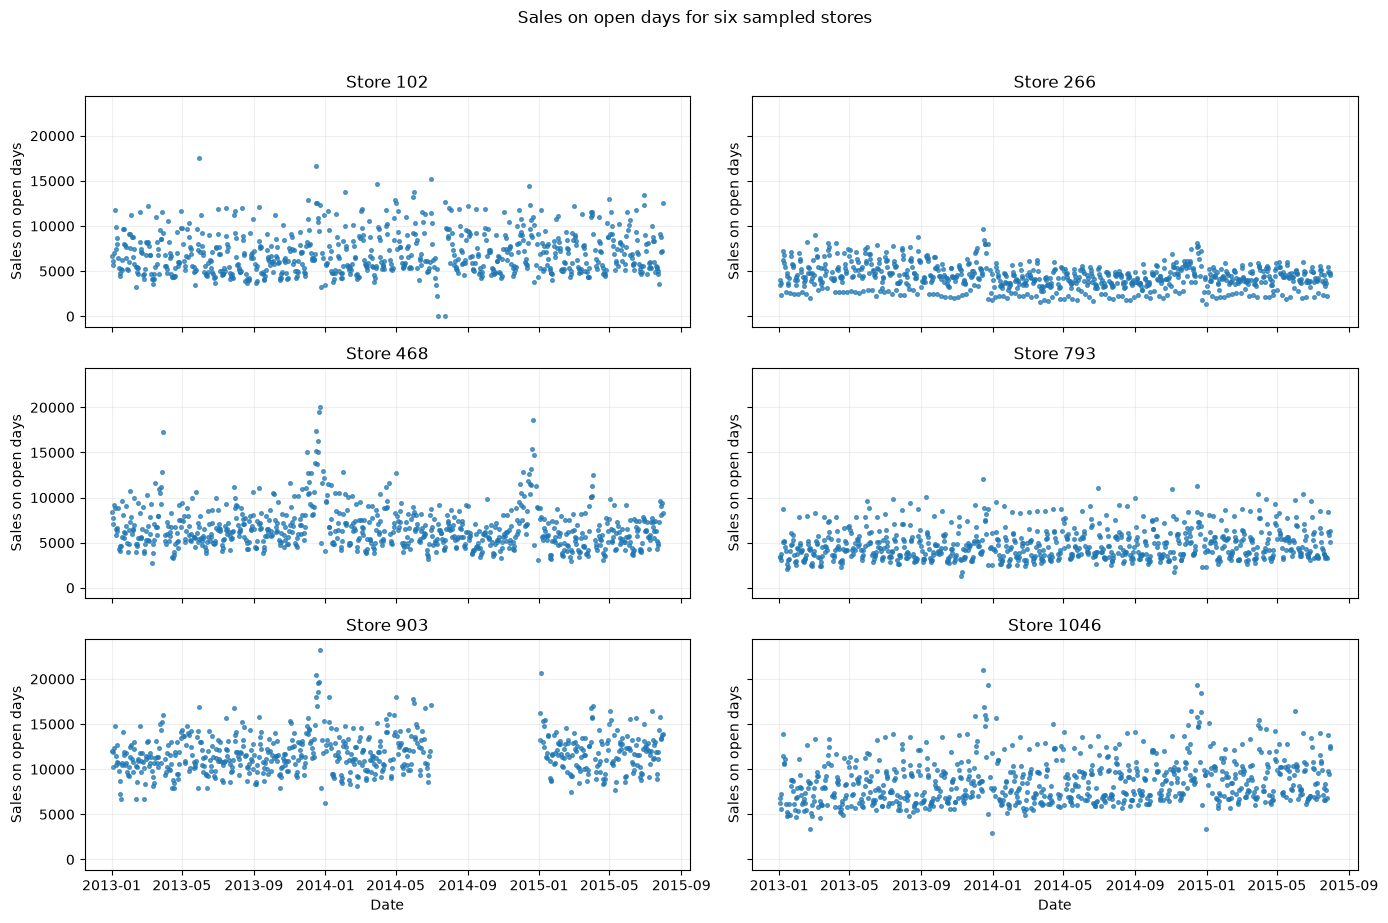

In [19]:
# Fix the seed so the same six example stores appear when the notebook is rerun.
sample_store_ids = (
    train_model["Store"].drop_duplicates().sample(n=6, random_state=42).sort_values()
)
# Missing dates are not closures, so they are counted rather than filled with zero.
expected_dates = pd.date_range(train_model["Date"].min(), train_model["Date"].max(), freq="D")
store_diagnostics = []
for store_id in sample_store_ids:
    store_rows = train_model.loc[train_model["Store"] == store_id].copy()
    open_rows = store_rows.loc[store_rows["Open"] == 1]
    sunday_rows = store_rows.loc[store_rows["Date"].dt.dayofweek == 6]
    store_diagnostics.append({
        "Store": store_id,
        "Recorded days": len(store_rows),
        "Missing dates": len(expected_dates.difference(pd.DatetimeIndex(store_rows["Date"]))),
        "Sundays recorded": len(sunday_rows),
        "Sundays open": int(sunday_rows["Open"].eq(1).sum()),
        "Other closed days": int(((store_rows["Open"] == 0) & (store_rows["Date"].dt.dayofweek != 6)).sum()),
        "Open days with zero Sales": int(((open_rows["Sales"] == 0)).sum()),
        "Open-day Sales median": open_rows["Sales"].median(),
        "Open-day Sales P10": open_rows["Sales"].quantile(0.10),
        "Open-day Sales P90": open_rows["Sales"].quantile(0.90),
    })
display(pd.DataFrame(store_diagnostics).set_index("Store").round(1))

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True, sharey=True)

for store_id, ax in zip(sample_store_ids, axes.flat):
    store_rows = train_model.loc[train_model["Store"] == store_id]
    open_days = store_rows.loc[store_rows["Open"] == 1].sort_values("Date")
    ax.scatter(open_days["Date"], open_days["Sales"], s=7, alpha=0.7)
    ax.set_title(f"Store {store_id}")
    ax.set_ylabel("Sales on open days")
    ax.grid(alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel("Date")

fig.suptitle("Sales on open days for six sampled stores", y=1.02)
plt.tight_layout()
plt.show()

Reading the six shops:

- In this sample, every recorded Sunday is closed, but the shops still close on other days, so the zero dips are not only a Sunday story.
- Store 102 also shows two open days with zero sales, the same inconsistency we flagged earlier.
- Opening patterns are not universal across the chain. Across all shops, 97.5 percent of Sundays are closed, but 2.5 percent are open and trading, so deleting every Sunday would throw away real trading days.
- The amount sold varies a lot between shops. The middle 80 percent of open days ranges from about 2,494 to 6,135 for one shop, and from about 9,159 to 14,405 for another. Those are real differences in scale, not artefacts.

This is a descriptive look at six shops, not a representative estimate and not a causal result. It filters to open days only to make the chart readable; nothing is removed from the data itself.


### 4.5 Which weekdays are busiest?

Next we compare the average and median sales for each weekday, again using open days only. This shows whether the day of the week carries a reliable pattern that a forecast should use.


,mean_sales,median_sales,store_days
Monday,8216.073074,7539.0,137560
Tuesday,7088.113656,6502.0,143961
Wednesday,6728.122978,6210.0,141936
Thursday,6767.310159,6246.0,134644
Friday,7072.677012,6580.0,138640
Saturday,5874.840238,5425.0,144058
Sunday,8224.723908,6876.0,3593


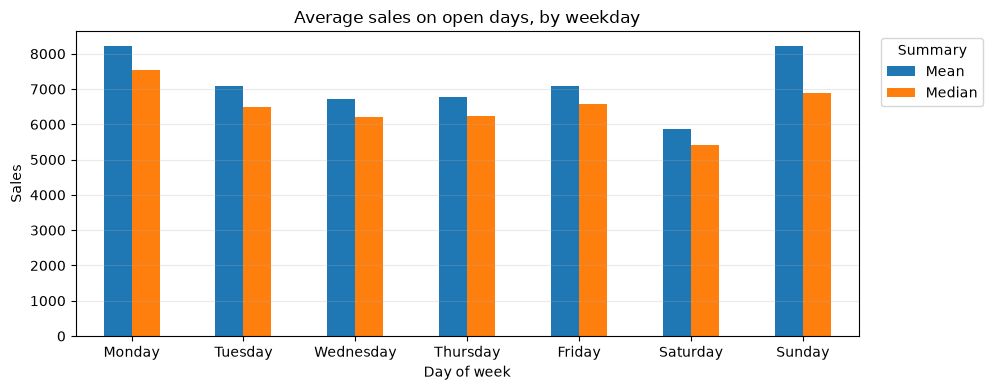

In [20]:
open_days = train_model.loc[train_model["Open"] == 1].copy()
weekday_names = {
    1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday",
    5: "Friday", 6: "Saturday", 7: "Sunday",
}
weekday_summary = (
    open_days.groupby("DayOfWeek", observed=True)["Sales"]
    .agg(mean_sales="mean", median_sales="median", store_days="size")
    .reindex(range(1, 8))
)
weekday_summary.index = [weekday_names[day] for day in weekday_summary.index]
display(weekday_summary)

ax = weekday_summary[["mean_sales", "median_sales"]].plot(
    kind="bar", figsize=(10, 4), rot=0,
)
ax.set(title="Average sales on open days, by weekday", xlabel="Day of week", ylabel="Sales")
ax.legend(
    ["Mean", "Median"], title="Summary", loc="upper left",
    bbox_to_anchor=(1.02, 1),
)
plt.tight_layout(rect=[0, 0, 0.84, 1])
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Reading the weekday profile: Saturday has the lowest average for an open day, around 5,875, while Monday and Sunday are the highest, around 8,200. But the Sunday figure needs care. Only 2.5 percent of Sunday shop-days are open (3,593 of 144,730), compared with roughly 134,000 to 144,000 for each other weekday, so the Sunday average describes the small minority of shops that trade on Sundays, not a typical shop's Sunday.

The lesson for forecasting is that the opening calendar is shop-specific. Some shops open on Sundays, most do not, and a forecast should follow each shop's own calendar rather than one blanket rule.


### 4.6 How sales move through the year

Sales can also move with the season. We plot the average sales per open day for each month in two ways: the simple average across all observed shop-days, and an equal-shop average that gives every complete-history shop the same weight. The shaded band marks the six months (July to December 2014) when 180 shops have no records, since that is where the two versions can diverge.


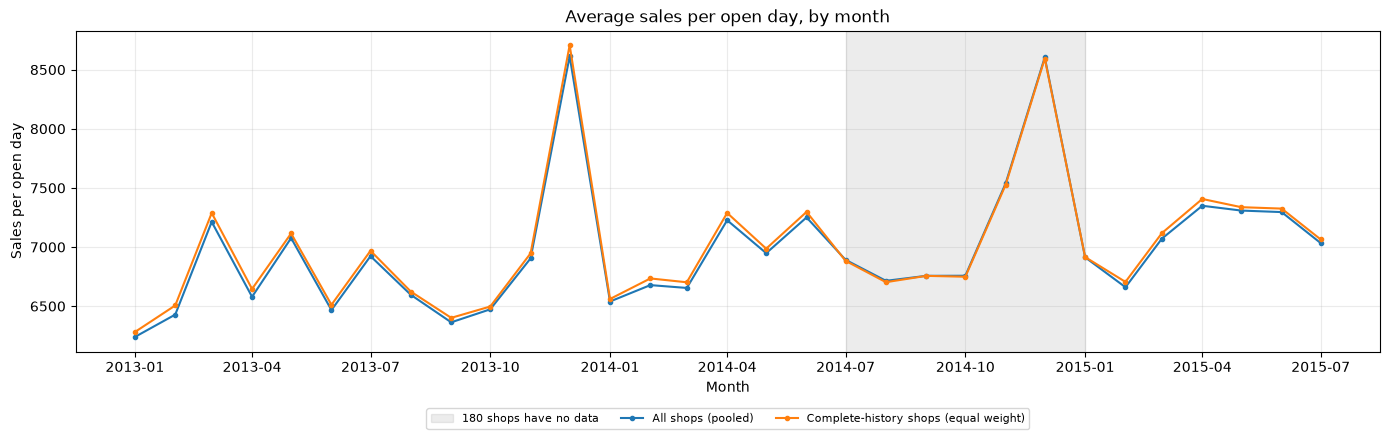

,pooled_open_day_mean,open_store_days,equal_store_mean,stores
Date,,,,
2013-01-01,6239.6,28869,6281.4,931
2013-02-01,6428.6,26683,6506.1,931
2013-03-01,7212.8,27892,7288.0,931
2013-04-01,6579.3,27880,6645.6,932
2013-05-01,7076.2,26202,7115.2,932
2013-06-01,6467.1,27942,6511.6,932
2013-07-01,6923.2,30166,6968.6,934
2013-08-01,6595.9,30025,6623.2,934
2013-09-01,6363.4,27981,6401.2,934


In [21]:
# Compare the raw pooled mean with a fixed cohort where every store has full date coverage.
all_store_month = (
    open_days.groupby(pd.Grouper(key="Date", freq="MS"))["Sales"]
    .agg(pooled_open_day_mean="mean", open_store_days="size")
)
complete_open_days = open_days.loc[open_days["Store"].isin(complete_store_ids)]
store_month_means = complete_open_days.groupby(
    [pd.Grouper(key="Date", freq="MS"), "Store"]
)["Sales"].mean()
complete_cohort_month = store_month_means.groupby(level=0).agg(
    equal_store_mean="mean", stores="size",
)
monthly_summary = all_store_month.join(complete_cohort_month)

fig, ax = plt.subplots(figsize=(14, 5))
ax.axvspan(
    pd.Timestamp("2014-07-01"), pd.Timestamp("2015-01-01"),
    color="gray", alpha=0.15, label="180 shops have no data",
)
ax.plot(
    monthly_summary.index, monthly_summary["pooled_open_day_mean"],
    marker=".", label="All shops (pooled)",
)
ax.plot(
    monthly_summary.index, monthly_summary["equal_store_mean"],
    marker=".", label="Complete-history shops (equal weight)",
)
ax.set(
    title="Average sales per open day, by month",
    xlabel="Month",
    ylabel="Sales per open day",
)
ax.grid(alpha=0.25)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=8)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
display(monthly_summary.round(1))

Reading the monthly movement:

- Coverage drops from 1,115 shops to 935 during the gap and then returns to 1,115. Over this particular stretch the two averages differ by no more than about 12 sales per open day, so the missing shops do not change the overall level much here.
- A seasonal shape is visible: sales peak in December and are lower in January and February. But with only two or three years of data we treat this as a pattern to test, not an established annual cycle. Promotion schedules, holidays and a general trend are all mixed into these monthly numbers.


,mean_sales,median_sales,store_months
Jan,6586.1,6269.3,2799
Feb,6648.8,6337.2,2799
Mar,7035.7,6709.5,2799
Apr,7113.9,6742.6,2800
May,7146.2,6806.1,2800
Jun,7044.9,6642.8,2799
Jul,6972.0,6617.3,2801
Aug,6663.0,6320.3,1867
Sep,6578.6,6244.6,1867
Oct,6622.9,6290.0,1868


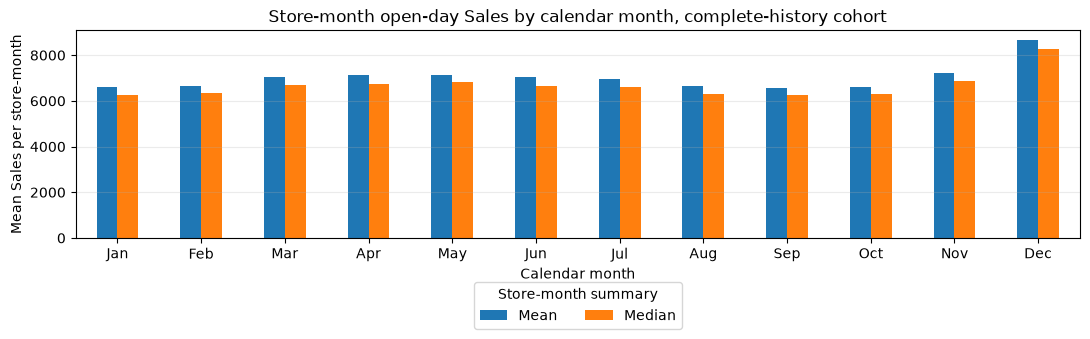

In [22]:
complete_store_months = complete_open_days.assign(
    MonthNumber=complete_open_days["Date"].dt.month,
    Month=complete_open_days["Date"].dt.to_period("M"),
).groupby(["Store", "Month", "MonthNumber"])["Sales"].mean()

month_of_year = (
    complete_store_months.reset_index()
    .groupby("MonthNumber")["Sales"]
    .agg(mean_sales="mean", median_sales="median", store_months="size")
    .reindex(range(1, 13))
)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_of_year.index = month_names
display(month_of_year.round(1))

ax = month_of_year[["mean_sales", "median_sales"]].plot(
    kind="bar", figsize=(11, 4), rot=0,
)
ax.set(
    title="Store-month open-day Sales by calendar month, complete-history cohort",
    xlabel="Calendar month",
    ylabel="Mean Sales per store-month",
)
ax.legend(["Mean", "Median"], title="Store-month summary", loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

Reading the month-of-year summary: after averaging within each shop and month so that no single shop can dominate, December is the strongest month (about 8,651 per open day) and January the weakest (about 6,586). Each shop-month counts equally, so this is not driven by a few large shops.

There is a caveat. January to July are seen in three years, but August to December in only two, because the history stops in July 2015. A strong December is consistent with a holiday-season lift, but two or three repeats are not enough to prove a stable seasonal effect or to explain why it happens.


### 4.7 Do promotions come with higher sales?

Promotions are one of the few influences we know in advance for a future day, so it is worth seeing how sales compare on promoted and non-promoted open days.


,mean_sales,median_sales,store_days
No daily promotion,5929.407603,5459.0,467496
Daily promotion,8228.281239,7649.0,376896


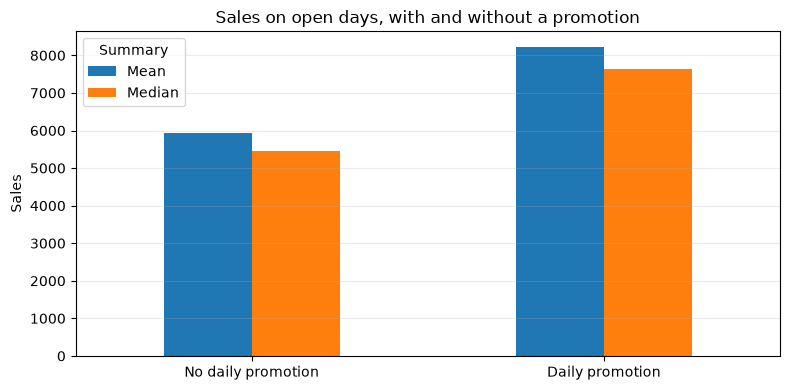

In [23]:
promo_summary = (
    open_days.groupby("Promo", observed=True)["Sales"]
    .agg(mean_sales="mean", median_sales="median", store_days="size")
    .reindex([0, 1])
)
promo_summary.index = ["No daily promotion", "Daily promotion"]
display(promo_summary)

ax = promo_summary[["mean_sales", "median_sales"]].plot(
    kind="bar", figsize=(8, 4), rot=0,
)
ax.set(title="Sales on open days, with and without a promotion", xlabel="", ylabel="Sales")
ax.legend(["Mean", "Median"], title="Summary")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Reading the promotion comparison: open days with a promotion average about 8,228 in sales, against about 5,929 without, a gap of roughly 39 percent in this pooled view.

That gap is an association, not proof that the promotion caused the extra sales. Promotions are not handed out at random: they may fall on busier weekdays, in busier seasons, or in busier shops. What we can say is that promotion is a sensible input for a forecast, because it is known ahead of time. What we cannot say from this table is how much of the difference the promotion itself creates.


### 4.8 Do different shop types sell differently?

Finally we compare the four shop formats (StoreType). So that a few large shops cannot dominate, we first reduce each shop to a single number, its average sales on an open day, and then compare those shop-level averages.


,mean_of_store_means,median_of_store_means,stores,complete_history_stores
StoreType,,,,
a,6912.542955,6481.216945,602,517
b,10110.779605,9744.599788,17,16
c,6917.199267,6645.840010,148,134
d,6823.743727,6695.215430,348,267


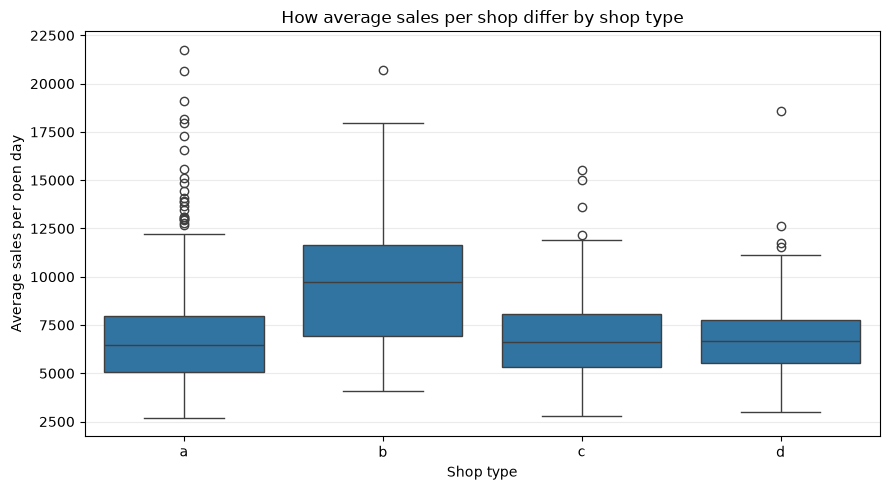

In [24]:
store_level_sales = (
    open_days.groupby(["Store", "StoreType"], observed=True)["Sales"]
    .mean()
    .rename("mean_open_day_sales")
    .reset_index()
)
store_level_sales["complete_history"] = store_level_sales["Store"].isin(complete_store_ids)

store_type_summary = (
    store_level_sales.groupby("StoreType", observed=True)
    .agg(
        mean_of_store_means=("mean_open_day_sales", "mean"),
        median_of_store_means=("mean_open_day_sales", "median"),
        stores=("Store", "size"),
        complete_history_stores=("complete_history", "sum"),
    )
)
display(store_type_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=store_level_sales, x="StoreType", y="mean_open_day_sales", ax=ax)
ax.set(
    title="How average sales per shop differ by shop type",
    xlabel="Shop type",
    ylabel="Average sales per open day",
)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Reading the shop-type comparison: type B shops have the highest average of shop averages, about 10,111 per open day, while types A, C and D sit close together around 6,800 to 6,900. But type B is rare, only 17 shops against 602 type A, 148 type C and 348 type D, so that high figure rests on a small group.

The box plot shows a wide spread within every type, including some very high shops, and that is the more useful message: shops differ a lot in scale even within a format. That is why the forecast lets each shop adapt through its own history rather than assuming one sales level for everyone. These are descriptive differences, not estimates of how the shop format causes sales.


### 4.9 What the exploration tells the forecast

Four things from this section shape the forecasting that follows:

- Shops follow different opening calendars, so the forecast needs the opening status for each shop and day.
- Sales on open days vary a lot, so a good forecast has to capture that variation, not just a yearly average.
- Promotions line up with higher sales and are known in advance, so they are worth including as an input.
- Shops differ widely in scale, so the models should let each shop's own level come through.

The exploration also taught us what to be careful about: the six-month gap in 180 shops, the small minority of shops that open on Sundays, and the fact that none of these patterns, on its own, proves a cause. For that reason the models are judged by how well they forecast held-out days, not by how convincing a pattern looks on a chart.


## 05 - FORECASTING SALES FOR EVERY STORE

This is the heart of the notebook. Instead of fitting a separate model to each shop, we train a single model across all 1,115 shops at once. The model learns the patterns that are common to the whole chain (the weekly rhythm, and the effect of promotions and holidays) while shop and history features let it adjust to each individual shop. This is called a **global** model, and it is the approach that scales to a dataset this size.

We compare several families of methods on exactly the same historical windows, rank them, and then use the best to produce a forecast for the competition period.


### 5.1 The families of methods we compare

Following the project checklist, the methods fall into four groups, from simplest to most complex:

- **Baselines:** naive forecasts (repeat the last value), seasonal naive (repeat the same weekday from last week), and simple and weighted moving averages. These are the yardsticks, and a serious model should beat them.
- **Classical statistical:** per-shop models, namely ETS (Holt-Winters), seasonal ARIMA, and seasonal ARIMA with calendar inputs, fitted separately to each shop; plus a single global ridge regression as the regression-family reference.
- **Machine learning:** LightGBM and XGBoost, each trained once across all shops using shop, calendar and history features.
- **Deep learning:** a global neural network (a multilayer perceptron with a shop embedding) and DeepAR, a recurrent model built for forecasting many related series.

The global models are ranked across all shops, which is the headline comparison. The classical per-shop models are covered separately, on the shops where they can be fitted.


### 5.2 What we forecast, and how we test it honestly

The thing we forecast is **recorded Sales**. Models are trained on open days, and closed days are set to zero, because we know in advance which days a shop is closed.

To compare methods fairly, we use **five separate 48-day windows** drawn from the history, one after another, spread across different seasons (autumn 2013, winter and spring 2014, and spring and summer 2015). For each window, every model sees only the data before the window and then forecasts the 48 days inside it. Because the windows sit at different points in the calendar, a model cannot win just by being suited to one season. Crucially, no window is ever used to train the model that predicts it.

This is the same logic a real deployment would follow: learn from the past, then predict a fixed block of the future.


### 5.3 How we measure forecast accuracy

Accuracy is summarised with two versions of the same measure, because they answer different questions:

- **Pooled RMSPE** is the measure the original competition used. It puts every positive-sales shop-day into one pot and reports the typical percentage error. By construction, big-selling shops contribute more to this number.
- **Macro RMSPE** first works out each shop's own percentage error, then averages across shops, so every shop counts the same regardless of size.

Reporting both stops a few large shops from hiding weak performance elsewhere. We also report two familiar absolute measures, MAE and WAPE, which are easier to read in sales units. Percentage errors ignore days with zero sales, because dividing by zero is impossible.


### 5.4 One table covering every shop and day

To train a model across the whole chain, we first lay the data out as a single grid: every shop against every calendar day. Days where a shop has no record are left blank rather than filled with zero, so the six-month gap stays visible for what it is.

For each shop-day we then build the inputs the models will use:

- **calendar information:** weekday, month, day of year, and smooth yearly cycles;
- **shop information:** shop type, assortment, distance to the nearest competitor, and promotion-programme flags;
- **known day information:** promotion, school holiday and state holiday;
- **the shop's own recent history:** sales on the previous 1, 7, 14, 28 and 56 days, plus rolling averages over the last 7 and 28 days.

Every history feature is built within each shop using a grouped shift, so a shop's "yesterday" is always its own previous day, never another shop's. Forgetting that grouping is the most common way to leak information between shops and to end up with a model that looks better than it really is.


In [25]:
import numpy as np
import pandas as pd

train = train.copy()
train["Date"] = pd.to_datetime(train["Date"])
stores = np.sort(train["Store"].unique())
store_index = {store_id: position for position, store_id in enumerate(stores)}
calendar = pd.date_range(train["Date"].min(), train["Date"].max(), freq="D")
panel = pd.MultiIndex.from_product([stores, calendar], names=["Store", "Date"]).to_frame(index=False)
panel = panel.merge(train, on=["Store", "Date"], how="left").merge(store, on="Store", how="left")
panel = panel.sort_values(["Store", "Date"]).reset_index(drop=True)

panel["store_code"] = panel["Store"].map(store_index).astype(int)
panel["StoreType"] = panel["StoreType"].astype("category").cat.codes
panel["Assortment"] = panel["Assortment"].astype("category").cat.codes
panel["day_of_week"] = panel["Date"].dt.dayofweek
panel["month"] = panel["Date"].dt.month
panel["day_of_year"] = panel["Date"].dt.dayofyear
panel["week_of_year"] = panel["Date"].dt.isocalendar().week.astype(float)
panel["weekday_sin"] = np.sin(2 * np.pi * panel["day_of_week"] / 7)
panel["weekday_cos"] = np.cos(2 * np.pi * panel["day_of_week"] / 7)
panel["year_sin"] = np.sin(2 * np.pi * (panel["day_of_year"] - 1) / 365.25)
panel["year_cos"] = np.cos(2 * np.pi * (panel["day_of_year"] - 1) / 365.25)
panel["competition_distance"] = np.log1p(panel["CompetitionDistance"])
panel["state_a"] = (panel["StateHoliday"] == "a").astype(float)
panel["state_b"] = (panel["StateHoliday"] == "b").astype(float)
panel["state_c"] = (panel["StateHoliday"] == "c").astype(float)

by_store = panel.groupby("Store", sort=False)["Sales"]
for lag in (1, 7, 14, 28, 56):
    panel[f"lag_{lag}"] = by_store.shift(lag)
shifted = by_store.shift(1)
panel["roll_7"] = shifted.groupby(panel["Store"], sort=False).rolling(7).mean().reset_index(level=0, drop=True)
panel["roll_28"] = shifted.groupby(panel["Store"], sort=False).rolling(28).mean().reset_index(level=0, drop=True)

FEATURES = ["day_of_week", "month", "day_of_year", "week_of_year", "weekday_sin", "weekday_cos",
            "year_sin", "year_cos", "competition_distance", "state_a", "state_b", "state_c",
            "Promo", "SchoolHoliday", "StoreType", "Assortment", "Promo2",
            "lag_1", "lag_7", "lag_14", "lag_28", "lag_56", "roll_7", "roll_28"]
DIRECT_FEATURES = [c for c in FEATURES if not c.startswith(("lag_", "roll_"))] + ["store_mean"]
NEURAL_FEATURES = FEATURES + ["store_mean"]

print(f"Panel: {panel.shape[0]:,} shop-days across {len(stores):,} shops")
print(f"Input features: {len(FEATURES)} for the tree models, {len(NEURAL_FEATURES)} for the neural network")


Panel: 1,050,330 shop-days across 1,115 shops
Input features: 24 for the tree models, 25 for the neural network


### 5.5 The models: baselines, regression, trees and a neural network

The baselines simply repeat the shop's recent values across the 48 days.

The global regression (ridge) uses the calendar and shop information but no sales history, so it predicts all 48 days in one go.

The tree models and the neural network use the full set of features and forecast **recursively**: they predict day one, then feed that prediction back in as the most recent history to predict day two, and so on for all 48 days. This mirrors how a real forecast is produced, because future sales are unknown while the forecast is being made. It also means small errors can build up over the horizon, which is why the windows are scored over the full 48 days rather than one day at a time.

Each method uses sensible fixed settings, applied identically to every window, so the comparison reflects the methods themselves. The neural network standardises its inputs, represents each shop by a short learned vector (an embedding), and is trained on raw sales because that target stays stable when the forecast is fed back recursively.


In [26]:
import torch
import torch.nn as nn
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

torch.manual_seed(42)
HORIZON = 48
fold_starts = [pd.Timestamp(day) for day in ["2013-10-05", "2014-01-04", "2014-04-04", "2015-03-10", "2015-06-14"]]
MODELS = ["Naive", "Seasonal naive", "Simple MA 7", "Weighted MA 7", "Ridge regression",
          "XGBoost", "LightGBM", "Neural network (MLP)"]


def score(actual, predicted):
    actual = np.asarray(actual, float)
    predicted = np.asarray(predicted, float)
    positive = actual > 0
    error = (actual[positive] - predicted[positive]) / actual[positive]
    return np.sqrt(np.mean(error ** 2)), np.mean(np.abs(actual - predicted)), np.sum(np.abs(actual - predicted)) / np.sum(actual)


def recursive_forecast(model, history_matrix, future_rows, feature_columns):
    predictions = np.empty(len(future_rows))
    running = history_matrix.copy()
    for day in sorted(future_rows["Date"].unique()):
        on_day = (future_rows["Date"] == day).to_numpy()
        features = future_rows.loc[on_day, feature_columns].copy()
        features["lag_1"] = running[-1]
        features["lag_7"] = running[-7]
        features["lag_14"] = running[-14]
        features["lag_28"] = running[-28]
        features["lag_56"] = running[-56]
        features["roll_7"] = running[-7:].mean(axis=0)
        features["roll_28"] = running[-28:].mean(axis=0)
        day_prediction = np.maximum(model.predict(features), 0)
        day_prediction = np.where(future_rows.loc[on_day, "Open"].to_numpy() == 0, 0.0, day_prediction)
        predictions[on_day] = day_prediction
        running = np.vstack([running, day_prediction])
    return predictions


class GlobalNeuralNet(nn.Module):
    def __init__(self, n_features, n_stores):
        super().__init__()
        self.embedding = nn.Embedding(n_stores, 16)
        self.mlp = nn.Sequential(
            nn.Linear(n_features + 16, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, features, store_codes):
        return self.mlp(torch.cat([features, self.embedding(store_codes)], dim=1)).squeeze(1)


def fit_neural_net(training, feature_columns, fill_value, epochs=6):
    table = training[feature_columns].fillna(fill_value).astype("float32")
    feature_mean = table.mean(axis=0).to_numpy()
    feature_std = np.where(table.std(axis=0).to_numpy() < 1e-3, 1.0, table.std(axis=0).to_numpy())
    features = np.ascontiguousarray(np.nan_to_num(np.clip((table.to_numpy() - feature_mean) / feature_std, -8, 8)).astype("float32"))
    target_raw = training["Sales"].to_numpy(dtype="float32")
    target_mean, target_std = float(target_raw.mean()), float(target_raw.std())
    target = ((target_raw - target_mean) / target_std).astype("float32")

    net = GlobalNeuralNet(len(feature_columns), len(stores))
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
    features_t = torch.tensor(features)
    target_t = torch.tensor(target)
    store_t = torch.tensor(training["store_code"].to_numpy(dtype="int64"))
    n = len(features_t)
    for epoch in range(epochs):
        order = torch.randperm(n)
        for start in range(0, n, 8192):
            index = order[start:start + 8192]
            optimizer.zero_grad()
            loss = nn.functional.mse_loss(net(features_t[index], store_t[index]), target_t[index])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)
            optimizer.step()
    net.eval()
    return net, (feature_mean, feature_std, target_mean, target_std)


def recursive_forecast_neural(net, scaling, history_matrix, future_rows, feature_columns, fill_value):
    feature_mean, feature_std, target_mean, target_std = scaling
    predictions = np.empty(len(future_rows))
    running = history_matrix.copy()
    for day in sorted(future_rows["Date"].unique()):
        on_day = (future_rows["Date"] == day).to_numpy()
        features = future_rows.loc[on_day, feature_columns].copy()
        features["lag_1"] = running[-1]
        features["lag_7"] = running[-7]
        features["lag_14"] = running[-14]
        features["lag_28"] = running[-28]
        features["lag_56"] = running[-56]
        features["roll_7"] = running[-7:].mean(axis=0)
        features["roll_28"] = running[-28:].mean(axis=0)
        table = features.fillna(fill_value).to_numpy(dtype=float)
        scaled = np.ascontiguousarray(np.nan_to_num(np.clip((table - feature_mean) / feature_std, -8, 8)).astype("float32"))
        with torch.no_grad():
            output = net(torch.tensor(scaled), torch.tensor(future_rows.loc[on_day, "store_code"].to_numpy(dtype="int64"))).numpy()
        day_prediction = np.maximum(np.clip(output, -1.0, 8.0) * target_std + target_mean, 0)
        day_prediction = np.where(future_rows.loc[on_day, "Open"].to_numpy() == 0, 0.0, day_prediction)
        predictions[on_day] = day_prediction
        running = np.vstack([running, day_prediction])
    return predictions


def run_validation_fold(fold_number, validation_start):
    validation_end = validation_start + pd.Timedelta(days=HORIZON - 1)
    training = panel[(panel["Date"] < validation_start) & panel["Open"].eq(1) & panel["Sales"].notna()].copy()
    validation = panel[(panel["Date"] >= validation_start) & (panel["Date"] <= validation_end)].copy()
    store_mean = training.groupby("Store")["Sales"].mean().rename("store_mean")
    training = training.join(store_mean, on="Store")
    validation = validation.join(store_mean, on="Store").sort_values(["Date", "Store"]).reset_index(drop=True)
    fill_value = training["competition_distance"].median()

    history = (panel[panel["Date"] < validation_start]
               .pivot_table(index="Date", columns="Store", values="Sales").sort_index().reindex(columns=stores))
    history_matrix = history.values
    open_flag = validation["Open"].to_numpy()

    seasonal = np.empty((HORIZON, len(stores)))
    for step in range(HORIZON):
        seasonal[step] = history_matrix[-7 + (step % 7)]
    baseline_forecasts = {
        "Naive": np.tile(history_matrix[-1], (HORIZON, 1)),
        "Seasonal naive": seasonal,
        "Simple MA 7": np.tile(history_matrix[-7:].mean(axis=0), (HORIZON, 1)),
        "Weighted MA 7": np.tile(history_matrix[-7:].T @ (np.arange(1, 8) / 28), (HORIZON, 1)),
    }
    store_position = {store_id: position for position, store_id in enumerate(stores)}
    for name, matrix in baseline_forecasts.items():
        aligned = np.empty(len(validation))
        for step, day in enumerate(sorted(validation["Date"].unique())):
            on_day = (validation["Date"] == day).to_numpy()
            aligned[on_day] = matrix[step, [store_position[s] for s in validation.loc[on_day, "Store"]]]
        validation[name] = np.where(open_flag == 0, 0.0, aligned)

    ridge = Ridge(alpha=1.0).fit(training[DIRECT_FEATURES].fillna(fill_value), training["Sales"])
    validation["Ridge regression"] = np.where(
        open_flag == 0, 0.0,
        np.maximum(ridge.predict(validation[DIRECT_FEATURES].fillna(fill_value)), 0),
    )

    xgboost = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                           colsample_bytree=0.8, reg_lambda=1.0, random_state=42, n_jobs=-1)
    lightgbm = LGBMRegressor(n_estimators=400, num_leaves=63, learning_rate=0.05, subsample=0.8,
                             subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0, random_state=42,
                             n_jobs=-1, verbosity=-1)
    xgboost.fit(training[FEATURES], training["Sales"])
    lightgbm.fit(training[FEATURES], training["Sales"])
    validation["XGBoost"] = recursive_forecast(xgboost, history_matrix, validation, FEATURES)
    validation["LightGBM"] = recursive_forecast(lightgbm, history_matrix, validation, FEATURES)

    net, scaling = fit_neural_net(training, NEURAL_FEATURES, fill_value)
    validation["Neural network (MLP)"] = recursive_forecast_neural(
        net, scaling, history_matrix, validation, NEURAL_FEATURES, fill_value,
    )
    validation["fold"] = fold_number
    return validation


validation_frames = [run_validation_fold(i + 1, start) for i, start in enumerate(fold_starts)]
global_validation = pd.concat(validation_frames, ignore_index=True)
print(f"Forecast rows scored across the five windows: {len(global_validation):,}")


Forecast rows scored across the five windows: 267,600


### 5.6 Ranking the models across all shops

The table below scores every model two ways (pooled and macro RMSPE) across all shops and all five windows. It is one thing to see a model come first; it is another to know whether the gap is real or just luck. So we add two checks:

- a **bootstrap** that resamples shops and asks how stable the gap between two models is, giving an interval that should be read like a confidence range, and
- a **per-shop win rate** that counts how often one model beats another, shop by shop.

Together these tell us whether a difference is solid or within noise.


In [27]:
def per_store_scores(frame):
    rows = []
    for store_id, group in frame.groupby("Store"):
        actual = group["Sales"].to_numpy(dtype=float)
        positive = actual > 0
        if not positive.any():
            continue
        record = {"Store": store_id, "open_days": int(positive.sum())}
        for model_name in MODELS:
            predicted = group[model_name].to_numpy(dtype=float)
            record[model_name] = float(np.sqrt(np.mean(((actual[positive] - predicted[positive]) / actual[positive]) ** 2)))
        rows.append(record)
    return pd.DataFrame(rows).set_index("Store")

store_scores = per_store_scores(global_validation)

ranking_rows = []
for model_name in MODELS:
    pooled, mae, wape = score(global_validation["Sales"], global_validation[model_name])
    ranking_rows.append({
        "model": model_name,
        "pooled RMSPE": pooled,
        "macro RMSPE": store_scores[model_name].mean(),
        "MAE": mae,
        "WAPE": wape,
    })
ranking = pd.DataFrame(ranking_rows).sort_values("pooled RMSPE").reset_index(drop=True)
print(f"Accuracy of each model across {store_scores.shape[0]:,} shops and five windows:")
display(ranking.round(4))


def cluster_bootstrap(model_a, model_b, reps=4000, seed=42):
    difference = (store_scores[model_a] - store_scores[model_b]).to_numpy()
    rng = np.random.default_rng(seed)
    n = len(difference)
    draws = np.array([difference[rng.integers(0, n, n)].mean() for _ in range(reps)])
    return difference.mean(), np.percentile(draws, 2.5), np.percentile(draws, 97.5)


leader = ranking["model"].iloc[0]
print("How stable is the leader's advantage? (negative means the leader has the lower error)")
for model_b in ["LightGBM", "Neural network (MLP)", "Ridge regression", "Seasonal naive"]:
    point, low, high = cluster_bootstrap(leader, model_b)
    print(f"  {leader} minus {model_b}: {point:+.4f} macro RMSPE, 95% interval [{low:+.4f}, {high:+.4f}]")

print("\nHow often the leader wins, shop by shop:")
for model_b in ["LightGBM", "Neural network (MLP)", "Ridge regression", "Seasonal naive"]:
    print(f"  {leader} beats {model_b} at {(store_scores[leader] < store_scores[model_b]).mean():.1%} of shops")


Accuracy of each model across 1,115 shops and five windows:


,model,pooled RMSPE,macro RMSPE,MAE,WAPE
0,XGBoost,0.2185,0.2115,818.4761,0.1419
1,LightGBM,0.2262,0.2200,845.6698,0.1466
2,Ridge regression,0.2328,0.2071,835.6354,0.1449
3,Neural network (MLP),0.2357,0.2072,737.6916,0.1279
4,Weighted MA 7,0.3294,0.3107,1549.1364,0.2686
5,Simple MA 7,0.3300,0.3130,1595.8954,0.2767
6,Naive,0.3560,0.3217,1363.1973,0.2364
7,Seasonal naive,0.3924,0.3878,1545.2988,0.2679


How stable is the leader's advantage? (negative means the leader has the lower error)
  XGBoost minus LightGBM: -0.0085 macro RMSPE, 95% interval [-0.0092, -0.0078]
  XGBoost minus Neural network (MLP): +0.0043 macro RMSPE, 95% interval [-0.0010, +0.0092]
  XGBoost minus Ridge regression: +0.0044 macro RMSPE, 95% interval [-0.0007, +0.0092]
  XGBoost minus Seasonal naive: -0.1763 macro RMSPE, 95% interval [-0.1791, -0.1732]

How often the leader wins, shop by shop:
  XGBoost beats LightGBM at 76.9% of shops
  XGBoost beats Neural network (MLP) at 29.6% of shops
  XGBoost beats Ridge regression at 33.9% of shops
  XGBoost beats Seasonal naive at 99.4% of shops


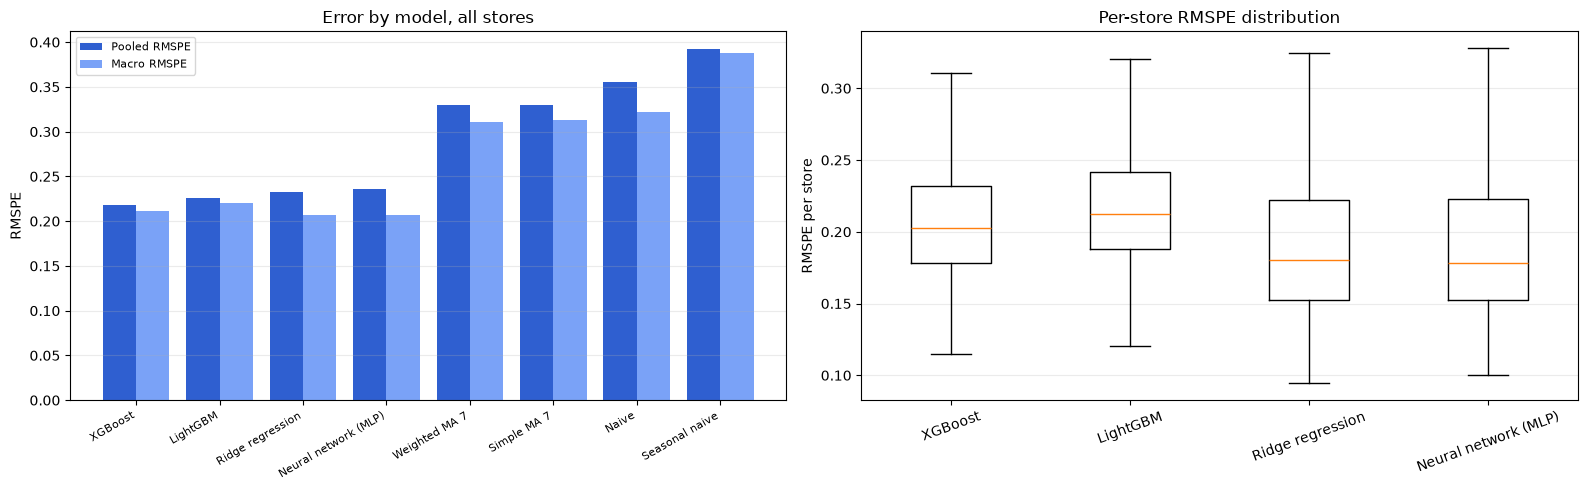

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
spread = ranking.sort_values("pooled RMSPE")
x = np.arange(len(spread))
axes[0].bar(x - 0.2, spread["pooled RMSPE"], width=0.4, label="Pooled RMSPE", color="#2f5fd0")
axes[0].bar(x + 0.2, spread["macro RMSPE"], width=0.4, label="Macro RMSPE", color="#7aa2f7")
axes[0].set_xticks(x); axes[0].set_xticklabels(spread["model"], rotation=30, ha="right", fontsize=8)
axes[0].set(title="Error by model, all stores", ylabel="RMSPE"); axes[0].grid(axis="y", alpha=0.25); axes[0].legend(fontsize=8)

top_models = list(spread["model"].head(4))
axes[1].boxplot([store_scores[m] for m in top_models], tick_labels=top_models, showfliers=False)
axes[1].set(title="Per-store RMSPE distribution", ylabel="RMSPE per store")
axes[1].grid(axis="y", alpha=0.25); axes[1].tick_params(axis="x", labelrotation=20)
plt.tight_layout(); plt.show()


Reading the ranking:

- On the competition's **pooled RMSPE**, XGBoost comes first (0.2185). On **macro RMSPE**, where every shop counts equally, the global ridge regression (0.2071) and the neural network (0.2072) edge slightly ahead of XGBoost (0.2115). So the "best" model depends on which measure we care about.
- The **per-shop win rate** makes the same point from the other side: XGBoost beats the neural network at only 29.6 percent of shops and ridge at 33.9 percent. On a typical shop the gap is small, even though XGBoost leads the size-weighted pooled number. A handful of very large shops account for that lead.
- The **bootstrap** clearly separates XGBoost from LightGBM, but does not separate XGBoost from the neural network or from ridge, whose intervals include zero. In other words, we have a leading **group**, not a single winner.
- The **gap down to the baselines is large and clear**, with intervals far from zero and win rates near 100 percent. That is the one comparison which needs no hedging.
- Adding four more seasonal windows narrowed the gaps between the top methods, compared with an earlier three-window version. That is the value of testing across seasons: it stops a single period from flattering one model.


### 5.7 Classical per-shop models, fitted to every shop

The classical methods (Holt-Winters, seasonal ARIMA, and ARIMA with calendar inputs) are per-shop models: each is fitted to one shop's own series. Here we fit them to **all 934 shops that have a complete, unbroken history**. The remaining 181 shops are left out, because a per-shop ARIMA cannot handle a series with a six-month hole in the middle.

That is 14,010 separate model fits across the five windows, and it is the slowest part of the notebook (roughly eight to ten minutes), so it runs across all available processor cores. To compare fairly with the rest, we score it the same way: one error per shop per window, then averaged.

This is the honest test of the classical family: not a couple of hand-picked shops, but every shop the method can actually fit.


In [29]:
import time
from joblib import Parallel, delayed

RESULTS_DIR = Path.cwd() / "results"


def per_series_forecast(store_id, store_history):
    import warnings
    import numpy as np
    import pandas as pd
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    rows = []
    for fold_number, origin in enumerate(fold_starts, start=1):
        end = origin + pd.Timedelta(days=HORIZON - 1)
        history = store_history[store_history["Date"] < origin]
        future = store_history[(store_history["Date"] >= origin) & (store_history["Date"] <= end)].sort_values("Date")
        if len(future) != HORIZON:
            continue
        series = pd.Series(history["Sales"].to_numpy(dtype=float), index=pd.DatetimeIndex(history["Date"]), name="Sales")
        open_flag = future["Open"].to_numpy()
        actual = future["Sales"].to_numpy(dtype=float)
        positive = actual > 0

        def exog(frame):
            return frame[["Open", "Promo", "SchoolHoliday", "state_a", "state_b", "state_c"]].astype(float).to_numpy()

        forecasts = {}
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                holt_winters = ExponentialSmoothing(series, trend="add", seasonal="add", seasonal_periods=7, initialization_method="estimated").fit(optimized=True)
                forecasts["ETS Holt-Winters"] = np.asarray(holt_winters.forecast(HORIZON), dtype=float)
            except Exception:
                pass
            try:
                sarima = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
                forecasts["SARIMA"] = np.asarray(sarima.forecast(HORIZON), dtype=float)
            except Exception:
                pass
            try:
                sarimax = SARIMAX(series, exog=exog(history), order=(1, 1, 1), seasonal_order=(1, 0, 1, 7), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
                forecasts["SARIMAX"] = np.asarray(sarimax.forecast(HORIZON, exog=exog(future)), dtype=float)
            except Exception:
                pass
        for name, values in forecasts.items():
            predicted = np.where(open_flag == 0, 0.0, np.maximum(values, 0))
            rmspe = float(np.sqrt(np.mean(((actual[positive] - predicted[positive]) / actual[positive]) ** 2))) if positive.any() else np.nan
            rows.append({"Store": int(store_id), "fold": fold_number, "model": name, "RMSPE": rmspe})
    return rows


completeness = panel.groupby("Store")["Sales"].count()
complete_stores = completeness[completeness == len(calendar)].index
history_by_store = {store_id: frame.sort_values("Date") for store_id, frame in panel[panel["Store"].isin(complete_stores)].groupby("Store")}
print(f"Fitting ETS, SARIMA and SARIMAX to each shop: {len(complete_stores)} shops with a complete history, {len(fold_starts)} windows each")
started = time.time()
fitted = Parallel(n_jobs=-1, max_nbytes=None)(delayed(per_series_forecast)(store_id, history_by_store[store_id]) for store_id in complete_stores)
stat_results = pd.DataFrame([row for sub in fitted for row in sub])
print(f"  {len(stat_results):,} model fits completed in {time.time() - started:,.0f} seconds")


def store_fold_macro(frame, name):
    return float(np.mean([
        np.sqrt(np.mean(((g["Sales"].to_numpy(float)[g["Sales"].to_numpy(float) > 0] - g[name].to_numpy(float)[g["Sales"].to_numpy(float) > 0]) / g["Sales"].to_numpy(float)[g["Sales"].to_numpy(float) > 0]) ** 2))
        for _, g in frame.groupby(["Store", "fold"]) if (g["Sales"] > 0).any()
    ]))


stat_summary = stat_results.groupby("model")["RMSPE"].mean().sort_values()
print(f"Average accuracy of the classical models across {stat_results['Store'].nunique()} shops ({len(stat_results):,} fits):")
display(stat_summary.round(4).to_frame("mean RMSPE (per shop and window)"))

global_complete = global_validation[global_validation["Store"].isin(complete_stores)]
comparison_rows = []
for name in ["LightGBM", "XGBoost", "Ridge regression", "Neural network (MLP)"]:
    comparison_rows.append({"model": name, "group": "Global", "mean store-window RMSPE": store_fold_macro(global_complete, name)})
for name, value in stat_summary.items():
    comparison_rows.append({"model": name, "group": "Classical statistical (per series)", "mean store-window RMSPE": value})
print("The same shops and windows, all four families side by side:")
display(pd.DataFrame(comparison_rows).sort_values("mean store-window RMSPE").set_index("model").round(4))


Fitting ETS, SARIMA and SARIMAX to each shop: 934 shops with a complete history, 5 windows each


  14,010 model fits completed in 529 seconds
Average accuracy of the classical models across 934 shops (14,010 fits):


,mean RMSPE (per shop and window)
model,
SARIMAX,0.2046
ETS Holt-Winters,0.2411
SARIMA,0.2574


The same shops and windows, all four families side by side:


,group,mean store-window RMSPE
model,,
XGBoost,Global,0.1971
Neural network (MLP),Global,0.2000
LightGBM,Global,0.2014
SARIMAX,Classical statistical (per series),0.2046
Ridge regression,Global,0.2083
ETS Holt-Winters,Classical statistical (per series),0.2411
SARIMA,Classical statistical (per series),0.2574


### 5.8 Deep learning: DeepAR across every shop

DeepAR is a deep-learning model built for exactly this situation: many related series that should be forecast together. It is trained once across all 1,115 shops as a single recurrent network, with the opening, promotion and holiday fields supplied as known future inputs, and it forecasts 48 days for each window. Because training a network involves randomness, we train three models per window with different seeds and average their forecasts, which makes the DeepAR result stable and directly comparable with the others. Training takes about fifteen minutes.

Other deep-learning forecasters exist, among them the Temporal Fusion Transformer (TFT), N-BEATS and transformer-based models. TFT was set up and tested on one window, but on this machine a single training epoch takes about 200 seconds and the model needs many, so it cannot be trained to a fair standard here. Those methods are named for completeness and left out of the ranking; a run on a GPU would add them.


In [30]:
import warnings
import tempfile
import torch
import lightning.pytorch as pl
from gluonts.dataset.common import ListDataset
from gluonts.transform import DummyValueImputation
from gluonts.torch import DeepAREstimator
from gluonts.torch.distributions import NormalOutput

all_stores = np.sort(panel["Store"].unique())


def store_matrix(column):
    return panel.pivot_table(index="Date", columns="Store", values=column).reindex(calendar).reindex(columns=all_stores).to_numpy()


sales_matrix = store_matrix("Sales")
open_matrix = store_matrix("Open")
dynamic = {"Open": open_matrix, "Promo": store_matrix("Promo"), "SchoolHoliday": store_matrix("SchoolHoliday"),
           "state_a": store_matrix("state_a"), "state_b": store_matrix("state_b"), "state_c": store_matrix("state_c")}
dynamic_names = list(dynamic)
start = pd.Period(calendar[0], freq="D")
seeds = [42, 123, 2024]


def deepar_datasets(origin):
    train_index = np.where(calendar < origin)[0]
    full_index = np.where(calendar <= origin + pd.Timedelta(days=HORIZON - 1))[0]
    train_entries, test_entries = [], []
    for j in range(len(all_stores)):
        target = sales_matrix[train_index, j].astype(float)
        train_features = [np.nan_to_num(dynamic[f][train_index, j].astype(float), nan=0.0).tolist() for f in dynamic_names]
        full_features = [np.nan_to_num(dynamic[f][full_index, j].astype(float), nan=0.0).tolist() for f in dynamic_names]
        train_entries.append({"start": start, "target": target, "feat_dynamic_real": train_features})
        test_entries.append({"start": start, "target": target, "feat_dynamic_real": full_features})
    return ListDataset(train_entries, freq="D"), ListDataset(test_entries, freq="D"), full_index


deepar_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for fold_number, origin in enumerate(fold_starts, start=1):
        training_set, test_set, full_index = deepar_datasets(origin)
        future_slice = full_index[-HORIZON:]
        dates_future = calendar[future_slice]
        seed_forecasts = []
        for seed in seeds:
            pl.seed_everything(seed, workers=True)
            estimator = DeepAREstimator(
                freq="D", prediction_length=HORIZON, context_length=64,
                distr_output=NormalOutput(), lr=5e-4, num_layers=2, hidden_size=40,
                num_feat_dynamic_real=len(dynamic_names),
                imputation_method=DummyValueImputation(0.0),
                batch_size=64, num_batches_per_epoch=50, num_parallel_samples=1000,
                trainer_kwargs={"max_epochs": 25, "accelerator": "cpu", "enable_progress_bar": False,
                                "enable_model_summary": False, "logger": False, "default_root_dir": tempfile.gettempdir(),
                                "gradient_clip_val": 10.0, "gradient_clip_algorithm": "norm", "deterministic": True},
            )
            predictor = estimator.train(training_set)
            seed_forecasts.append(np.stack([np.asarray(forecast.mean) for forecast in predictor.predict(test_set)]))
        averaged = np.mean(seed_forecasts, axis=0)
        for j in range(len(all_stores)):
            predicted = np.where(open_matrix[future_slice, j] == 0, 0.0, np.maximum(averaged[j], 0))
            actual = sales_matrix[future_slice, j].astype(float)
            for k in range(HORIZON):
                deepar_rows.append({"Store": int(all_stores[j]), "fold": fold_number, "Date": dates_future[k],
                                    "actual": float(actual[k]), "predicted": float(predicted[k])})
        print(f"DeepAR finished window {fold_number} (forecast starting {origin.date()}), averaging {len(seeds)} seeds")

deepar = pd.DataFrame(deepar_rows)
_da = deepar["actual"].to_numpy(float)
_dp = deepar["predicted"].to_numpy(float)
_positive = _da > 0
deepar_pooled = float(np.sqrt(np.mean(((_da[_positive] - _dp[_positive]) / _da[_positive]) ** 2)))
_deepar_macro = float(np.mean([
    np.sqrt(np.mean(((g["actual"].to_numpy(float)[g["actual"].to_numpy(float) > 0] - g["predicted"].to_numpy(float)[g["actual"].to_numpy(float) > 0]) / g["actual"].to_numpy(float)[g["actual"].to_numpy(float) > 0]) ** 2))
    for _, g in deepar.groupby("Store") if (g["actual"] > 0).any()
]))

combined = []
for name in ["XGBoost", "LightGBM", "Ridge regression", "Neural network (MLP)"]:
    family = "Machine learning" if ("XGBoost" in name or "LightGBM" in name) else ("Regression" if name == "Ridge regression" else "Deep learning (MLP)")
    combined.append({"model": name, "family": family, "pooled RMSPE": score(global_validation["Sales"], global_validation[name])[0], "macro RMSPE": store_scores[name].mean()})
combined.append({"model": "DeepAR (3-seed average)", "family": "Deep learning (DeepAR)", "pooled RMSPE": deepar_pooled, "macro RMSPE": _deepar_macro})
print("All 1,115 shops across the five windows, now including the deep models:")
display(pd.DataFrame(combined).sort_values("pooled RMSPE").set_index("model").round(4))


Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Epoch 0, global step 50: 'train_loss' reached 8448700443018590884462592.00000 (best 8448700443018590884462592.00000), saving model to 'C:\\Users\\admin\\AppData\\Local\\Temp\\checkpoints\\epoch=0-step=50.ckpt' as top 1


...

Epoch 24, global step 1250: 'train_loss' was not in top 1


`Trainer.fit` stopped: `max_epochs=25` reached.


DeepAR finished window 5 (forecast starting 2015-06-14), averaging 3 seeds


All 1,115 shops across the five windows, now including the deep models:


,family,pooled RMSPE,macro RMSPE
model,,,
XGBoost,Machine learning,0.2185,0.2115
DeepAR (3-seed average),Deep learning (DeepAR),0.2247,0.2185
LightGBM,Machine learning,0.2262,0.2200
Ridge regression,Regression,0.2328,0.2071
Neural network (MLP),Deep learning (MLP),0.2357,0.2072


### 5.9 What the forecasts look like

A score compresses a forecast into one number. The classic forecasting picture is more direct: the recent past as one line, then the forecast period with one line per method, so the shape and the differences are visible.

The first chart shows total daily sales across all shops with a complete history. The recent past is drawn as a single line, and then each approach forecasts a held-out window. Because that window is historical, the actual sales are drawn as well, so the gap between each forecast and reality can be seen directly. The simple baselines flatten the weekly rhythm, while the classical, tree, neural and DeepAR forecasts follow it.

The second chart shows how the error grows as the forecast reaches further ahead, from day 1 to day 48, averaged over every shop and window. Six weeks is the real planning horizon, so it matters that a method stays accurate far out, not only on the first day. The table underneath gives those same errors as numbers, week by week.


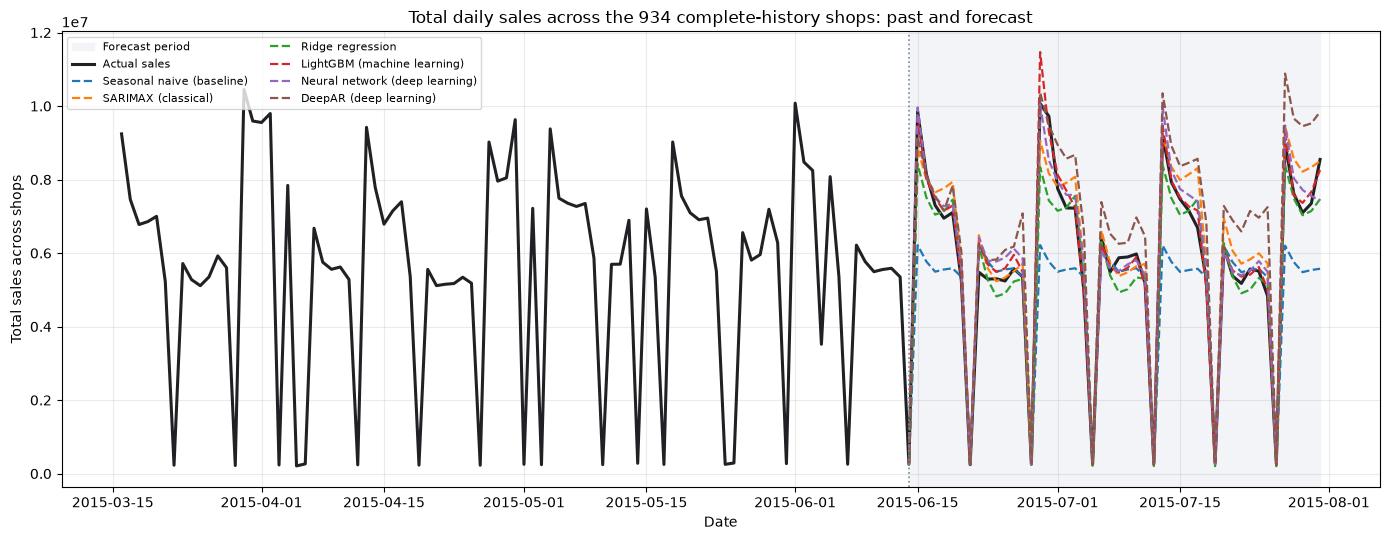

In [31]:
# Total daily sales for every complete-history shop: the recent past, then each approach's forecast.
from joblib import Parallel, delayed

window = fold_starts[-1]
window_end = window + pd.Timedelta(days=HORIZON - 1)
complete = list(complete_store_ids)
history_start = window - pd.Timedelta(days=90)


def classical_daily(store_id, store_history):
    import warnings as _warnings
    import numpy as _np
    import pandas as _pd
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    history = store_history[store_history["Date"] < window]
    future = store_history[(store_history["Date"] >= window) & (store_history["Date"] <= window_end)].sort_values("Date")
    series = _pd.Series(history["Sales"].to_numpy(float), index=_pd.DatetimeIndex(history["Date"]))
    exog = ["Open", "Promo", "SchoolHoliday", "state_a", "state_b", "state_c"]
    with _warnings.catch_warnings():
        _warnings.simplefilter("ignore")
        try:
            fit = SARIMAX(series, exog=history[exog].astype(float).to_numpy(), order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
            prediction = _np.asarray(fit.forecast(len(future), exog=future[exog].astype(float).to_numpy()), float)
        except Exception:
            prediction = _np.zeros(len(future))
    return store_id, _np.where(future["Open"].to_numpy() == 0, 0.0, _np.maximum(prediction, 0))


classical_parts = Parallel(n_jobs=-1, max_nbytes=None)(delayed(classical_daily)(s, history_by_store[s]) for s in complete)
classical_total = np.sum(np.vstack([part for _, part in classical_parts]), axis=0)

gv = global_validation[(global_validation["Date"] >= window) & (global_validation["Store"].isin(complete))]
dates = sorted(gv["Date"].unique())
actual_window = gv.groupby("Date")["Sales"].sum().reindex(dates)
deepar_window = deepar[(deepar["Date"] >= window) & (deepar["Store"].isin(complete))].groupby("Date")["predicted"].sum().reindex(dates)
history = panel[(panel["Store"].isin(complete)) & (panel["Date"] >= history_start) & (panel["Date"] < window)].groupby("Date")["Sales"].sum()
actual_full = pd.concat([history, actual_window])

methods = {
    "Seasonal naive (baseline)": gv.groupby("Date")["Seasonal naive"].sum().reindex(dates),
    "SARIMAX (classical)": pd.Series(classical_total, index=dates),
    "Ridge regression": gv.groupby("Date")["Ridge regression"].sum().reindex(dates),
    "LightGBM (machine learning)": gv.groupby("Date")["LightGBM"].sum().reindex(dates),
    "Neural network (deep learning)": gv.groupby("Date")["Neural network (MLP)"].sum().reindex(dates),
    "DeepAR (deep learning)": deepar_window,
}

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.axvspan(window, window_end, color="#f2f4f7", zorder=0, label="Forecast period")
ax.plot(actual_full.index, actual_full.to_numpy(), color="#202124", linewidth=2.2, label="Actual sales")
colors = plt.get_cmap("tab10").colors
for index, (name, values) in enumerate(methods.items()):
    ax.plot(values.index, values.to_numpy(), color=colors[index], linestyle="--", linewidth=1.6, label=name)
ax.axvline(window, color="#7c8798", linestyle=":", linewidth=1.2)
ax.set(title=f"Total daily sales across the {len(complete)} complete-history shops: past and forecast",
       xlabel="Date", ylabel="Total sales across shops")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()


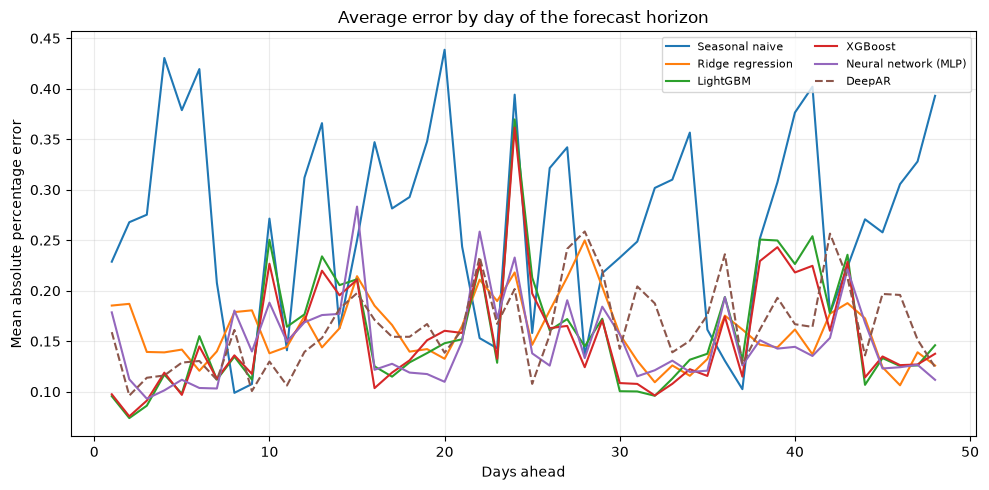

In [32]:
# How the error grows as the forecast reaches further ahead.
horizon_frame = global_validation.sort_values(["fold", "Store", "Date"]).copy()
horizon_frame["horizon"] = horizon_frame.groupby(["fold", "Store"]).cumcount() + 1
horizon_methods = ["Seasonal naive", "Ridge regression", "LightGBM", "XGBoost", "Neural network (MLP)"]

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.get_cmap("tab10").colors
for index, name in enumerate(horizon_methods):
    error = (horizon_frame["Sales"] - horizon_frame[name]).abs() / horizon_frame["Sales"].where(horizon_frame["Sales"] > 0)
    curve = error.groupby(horizon_frame["horizon"]).mean()
    ax.plot(curve.index, curve.to_numpy(), label=name, color=colors[index])

deepar_horizon = deepar.sort_values(["fold", "Store", "Date"]).copy()
deepar_horizon["horizon"] = deepar_horizon.groupby(["fold", "Store"]).cumcount() + 1
deepar_error = (deepar_horizon["actual"] - deepar_horizon["predicted"]).abs() / deepar_horizon["actual"].where(deepar_horizon["actual"] > 0)
deepar_curve = deepar_error.groupby(deepar_horizon["horizon"]).mean()
ax.plot(deepar_curve.index, deepar_curve.to_numpy(), label="DeepAR", color=colors[5], linestyle="--")

ax.set(title="Average error by day of the forecast horizon", xlabel="Days ahead", ylabel="Mean absolute percentage error")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


In [33]:
# The numbers behind the previous chart: average error in each week of the horizon.
horizon_table = {}
for name in horizon_methods:
    error = (horizon_frame["Sales"] - horizon_frame[name]).abs() / horizon_frame["Sales"].where(horizon_frame["Sales"] > 0)
    horizon_table[name] = error.groupby(horizon_frame["horizon"]).mean()
horizon_table["DeepAR"] = deepar_error.groupby(deepar_horizon["horizon"]).mean()
horizon_table = pd.DataFrame(horizon_table)

weekly = horizon_table.groupby((horizon_table.index - 1) // 7 + 1).mean()
weekly.index = [f"days {7 * (week - 1) + 1}-{min(7 * week, HORIZON)}" for week in weekly.index]
table = weekly.T
table["all 48 days"] = horizon_table.mean()
table.index.name = "method"
print("Average absolute percentage error by week of the horizon (all shops and windows):")
display(table.round(4))


Average absolute percentage error by week of the horizon (all shops and windows):


,days 1-7,days 8-14,days 15-21,days 22-28,days 29-35,days 36-42,days 43-48,all 48 days
method,,,,,,,,
Seasonal naive,0.3155,0.2086,0.3144,0.2354,0.2612,0.2498,0.2964,0.2682
Ridge regression,0.1504,0.1605,0.1636,0.2013,0.1392,0.1576,0.1427,0.1597
LightGBM,0.1054,0.1825,0.1455,0.2021,0.1216,0.2120,0.1455,0.1595
XGBoost,0.1054,0.1735,0.1477,0.1959,0.1184,0.1950,0.1448,0.1546
Neural network (MLP),0.1149,0.1685,0.1470,0.1788,0.1355,0.1495,0.1459,0.1486
DeepAR,0.1223,0.1389,0.1635,0.1952,0.1742,0.1865,0.1695,0.1642


### 5.10 Producing the final forecast for the competition period

The competition hides the actual sales for 1 August to 17 September 2015, so these forecasts cannot be scored. What we can do is refit the two strongest global methods on the entire history and produce a forecast for every shop and date in the test file.

Known closed days are set to zero. The 11 test rows with an unknown opening status (all Store 622) are forecast as open and flagged, because an unknown status should never be silently treated as closed. The leading model is also given an 80% prediction interval, learned from how far its forecasts fell short or overshot on the backtest, so the final output is a range rather than a single number. The chart shows the recent past and then the competition-period forecast for the two leading models, with the 80% interval drawn as a band. Everything is written to CSV in the format the competition expects.


In [34]:
test_stores = np.sort(test["Store"].unique())
test_panel = test.merge(store, on="Store", how="left").copy()
test_panel["Store"] = test_panel["Store"].astype(int)
test_panel["store_code"] = test_panel["Store"].map(store_index).astype(int)
test_panel["StoreType"] = test_panel["StoreType"].astype("category").cat.codes
test_panel["Assortment"] = test_panel["Assortment"].astype("category").cat.codes
test_panel["Date"] = pd.to_datetime(test_panel["Date"])
test_panel["day_of_week"] = test_panel["Date"].dt.dayofweek
test_panel["month"] = test_panel["Date"].dt.month
test_panel["day_of_year"] = test_panel["Date"].dt.dayofyear
test_panel["week_of_year"] = test_panel["Date"].dt.isocalendar().week.astype(float)
test_panel["weekday_sin"] = np.sin(2 * np.pi * test_panel["day_of_week"] / 7)
test_panel["weekday_cos"] = np.cos(2 * np.pi * test_panel["day_of_week"] / 7)
test_panel["year_sin"] = np.sin(2 * np.pi * (test_panel["day_of_year"] - 1) / 365.25)
test_panel["year_cos"] = np.cos(2 * np.pi * (test_panel["day_of_year"] - 1) / 365.25)
test_panel["competition_distance"] = np.log1p(test_panel["CompetitionDistance"])
test_panel["state_a"] = (test_panel["StateHoliday"] == "a").astype(float)
test_panel["state_b"] = (test_panel["StateHoliday"] == "b").astype(float)
test_panel["state_c"] = (test_panel["StateHoliday"] == "c").astype(float)
for lag in (1, 7, 14, 28, 56):
    test_panel[f"lag_{lag}"] = np.nan
test_panel["roll_7"] = np.nan
test_panel["roll_28"] = np.nan
test_panel["Open"] = pd.to_numeric(test_panel["Open"], errors="coerce")
test_panel = test_panel.sort_values(["Date", "Store"]).reset_index(drop=True)

full_training = panel[panel["Open"].eq(1) & panel["Sales"].notna()]
full_fill = full_training["competition_distance"].median()
full_store_mean = full_training.groupby("Store")["Sales"].mean().rename("store_mean")
full_training = full_training.join(full_store_mean, on="Store")
test_panel = test_panel.join(full_store_mean, on="Store")
history = panel.pivot_table(index="Date", columns="Store", values="Sales").sort_index().reindex(columns=test_stores)

final_lightgbm = LGBMRegressor(n_estimators=400, num_leaves=63, learning_rate=0.05, subsample=0.8,
                               subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0, random_state=42,
                               n_jobs=-1, verbosity=-1)
final_lightgbm.fit(full_training[FEATURES], full_training["Sales"])
final_net, final_scaling = fit_neural_net(full_training.assign(store_mean=full_training["store_mean"]), NEURAL_FEATURES, full_fill)

submission_dir = RESULTS_DIR / "submissions"
submission_dir.mkdir(parents=True, exist_ok=True)
submissions = {
    "LightGBM": recursive_forecast(final_lightgbm, history.values, test_panel, FEATURES),
    "MLP": recursive_forecast_neural(final_net, final_scaling, history.values, test_panel, NEURAL_FEATURES, full_fill),
}

unknown_open = int(test_panel["Open"].isna().sum())
for name, predictions in submissions.items():
    table = test_panel[["Id"]].copy()
    table["Sales"] = predictions
    path = submission_dir / f"submission_{name.lower()}.csv"
    table.sort_values("Id").to_csv(path, index=False)
    print(f"{path.name}: {len(table):,} rows for {test_panel['Store'].nunique():,} shops, {table['Sales'].sum():,.0f} sales in total")
print(f"Test rows with an unknown opening status, forecast as open: {unknown_open}")
display(pd.DataFrame({"Id": test_panel["Id"], "LightGBM": submissions["LightGBM"], "MLP": submissions["MLP"]}).head())


submission_lightgbm.csv: 41,088 rows for 856 shops, 242,739,707 sales in total
submission_mlp.csv: 41,088 rows for 856 shops, 228,159,796 sales in total
Test rows with an unknown opening status, forecast as open: 11


,Id,LightGBM,MLP
0,40233,4426.184590,4085.536621
1,40234,4310.182866,4386.246094
2,40235,7617.127012,8282.986328
3,40236,3579.830019,3851.301270
4,40237,6504.276350,6236.217285


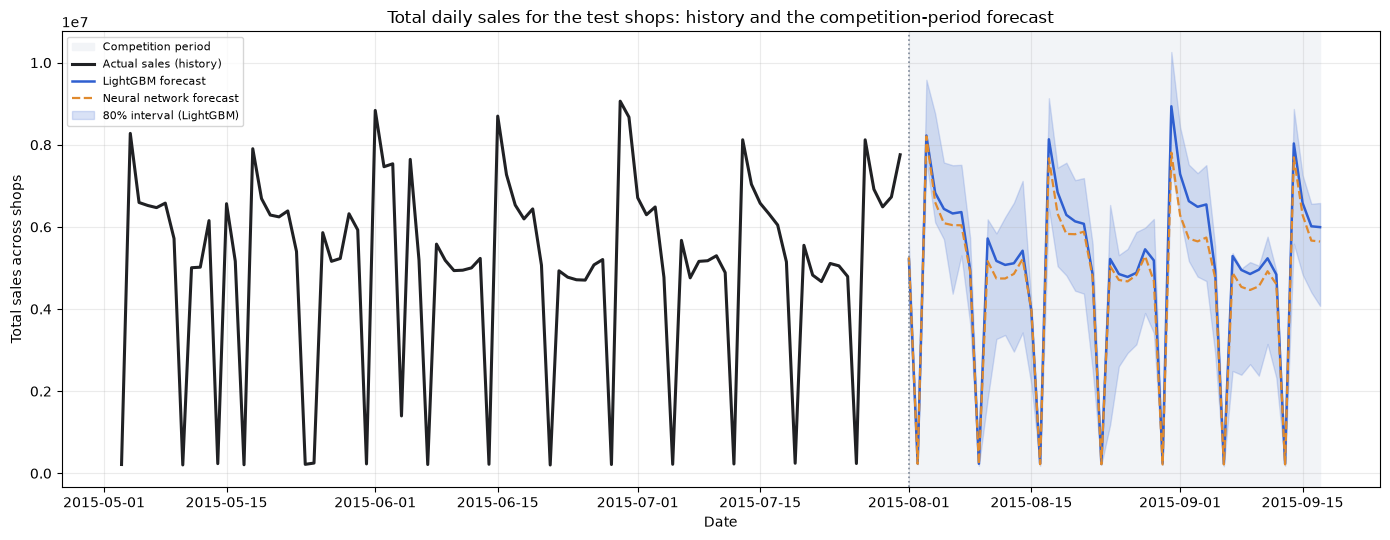

Typical 80% interval on an open day: about 46% of the forecast


In [35]:
# An 80% prediction interval for the test forecast, learned from the backtest errors.
backtest = global_validation.sort_values(["fold", "Store", "Date"]).copy()
backtest["horizon"] = backtest.groupby(["fold", "Store"]).cumcount() + 1
backtest["relative_error"] = (backtest["Sales"] - backtest["LightGBM"]) / backtest["Sales"].where(backtest["Sales"] > 0)
band = backtest.dropna(subset=["relative_error"]).groupby("horizon")["relative_error"].quantile([0.1, 0.9]).unstack()
band.columns = ["low", "high"]

test_panel["horizon"] = (test_panel["Date"] - test_panel["Date"].min()).dt.days + 1
base = submissions["LightGBM"]
lower = np.maximum(base * (1 + test_panel["horizon"].map(band["low"]).to_numpy()), 0)
upper = np.maximum(base * (1 + test_panel["horizon"].map(band["high"]).to_numpy()), 0)

interval = pd.DataFrame({"Id": test_panel["Id"], "Sales": base, "Sales_lower": lower, "Sales_upper": upper}).sort_values("Id")
interval.to_csv(submission_dir / "submission_lightgbm_with_interval.csv", index=False)
history_start = test_panel["Date"].min() - pd.Timedelta(days=90)
history_chain = panel[(panel["Store"].isin(test_stores)) & (panel["Date"] >= history_start) & (panel["Date"] < test_panel["Date"].min())].groupby("Date")["Sales"].sum()
chain = test_panel.assign(lgbm=base, mlp=submissions["MLP"], lower=lower, upper=upper).groupby("Date")[["lgbm", "mlp", "lower", "upper"]].sum()

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.axvspan(test_panel["Date"].min(), test_panel["Date"].max(), color="#f2f4f7", zorder=0, label="Competition period")
ax.plot(history_chain.index, history_chain.to_numpy(), color="#202124", linewidth=2.2, label="Actual sales (history)")
ax.plot(chain.index, chain["lgbm"], color="#2f5fd0", linewidth=1.8, label="LightGBM forecast")
ax.plot(chain.index, chain["mlp"], color="#e08a2e", linewidth=1.6, linestyle="--", label="Neural network forecast")
ax.fill_between(chain.index, chain["lower"], chain["upper"], color="#2f5fd0", alpha=0.18, label="80% interval (LightGBM)")
ax.axvline(test_panel["Date"].min(), color="#7c8798", linestyle=":", linewidth=1.2)
ax.set(title="Total daily sales for the test shops: history and the competition-period forecast",
       xlabel="Date", ylabel="Total sales across shops")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()
width = (upper - lower) / np.where(base > 0, base, np.nan)
print(f"Typical 80% interval on an open day: about {np.nanmedian(width):.0%} of the forecast")


Reading the output: both CSV files follow the competition layout (Id, Sales) and cover every test row. Because the real sales are withheld, nothing here can be scored; these are scenarios built the same way a competition entry would be. The 11 unknown-status rows are forecast rather than zeroed, and any real use would replace that placeholder with a validated rule.

The result we can actually check is the ranking in section 5.6, which is measured on real history. These test forecasts are simply the deployable output built from the leading methods.


## 06 - CONCLUSIONS

### 6.1 What this study supports

Across 1,115 shops on five windows spread over four seasons, the modern global models were the most accurate and the naive baselines the least.

- On the competition's pooled RMSPE, **XGBoost leads (0.2185)**.
- On macro RMSPE, where every shop counts equally, the **ridge regression (0.2071)** and the **neural network (0.2072)** edge slightly ahead of XGBoost (0.2115).
- The per-shop win rate agrees: XGBoost beats the neural network at 29.6 percent of shops and ridge at 33.9 percent, so a few large shops carry its pooled lead.
- A bootstrap separates XGBoost from LightGBM but not from the neural network or ridge. XGBoost, LightGBM, the neural network and ridge form a tight **leading group**, and DeepAR, trained as a three-seed average, together with the classical per-shop SARIMAX, sit inside that same group.
- The gap down to the baselines is large and unambiguous.

In plain terms, a single global model that learns across all shops is a strong and practical way to forecast this dataset, and the leading group spans machine learning, deep learning and regression. Which member is best depends on whether the priority is total sales or the typical shop.

### 6.2 Where to take it next

1. Train TFT, N-BEATS and transformer models on a GPU and add them to the ranking.
2. Add more windows and later seasons, to test the ranking further.
3. Break the errors down by weekday, promotion, holiday and shop type, to confirm no shop group is being missed.
4. Extend the 80% interval, now produced for the leading model, to every method in the table.
5. Replace the placeholder handling of the 11 unknown opening-status rows with a validated rule before a real submission.

Throughout, the target is recorded Sales. Known closures are set to zero after prediction, and forecasts are never allowed to go negative.


### References: forecasting

- [Forecasting: Principles and Practice, simple forecasting methods](https://otexts.com/fpp3/simple-methods.html)
- [Forecasting: Principles and Practice, ARIMA models](https://otexts.com/fpp3/arima.html)
- [Forecasting: Principles and Practice, regression forecasting](https://otexts.com/fpp3/forecasting-regression.html)
- [Forecasting: Principles and Practice, time-series cross-validation](https://otexts.com/fpp3/tscv.html)
- [Prophet quick start](https://facebook.github.io/prophet/docs/quick_start.html)
- [DeepAR paper](https://arxiv.org/abs/1704.04110) and [Temporal Fusion Transformers paper](https://arxiv.org/abs/1912.09363)
- Rossmann competition description and RMSPE definition in datasets/rossmann-store-sales/README.md

These references support method definitions. Forecast scores reported above are from the local Rossmann data and the stated backtest only.

### References: EDA and data handling

- [NIST/SEMATECH e-Handbook: What is EDA?](https://www.itl.nist.gov/div898/handbook/eda/section1/eda11.htm)
- [Forecasting: Principles and Practice, time-series graphics](https://otexts.com/fpp3/graphics.html)
- [Seaborn, visualizing categorical data](https://seaborn.pydata.org/tutorial/categorical.html)
- [Scikit-learn, common pitfalls and data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)

The dataset-specific interpretation comes from the supplied Rossmann documentation and observed row-level checks. Missing and inconsistent values are reported rather than silently repaired.